## COVID-19 Data Analysis

This notebook uses the merged dataset to answer questions about the pandemic across 200+ countries, grouped into six themes: **(A)** descriptive overview, **(B)** government response, **(C)** vaccination impact, **(D)** hospital pressure, **(E)** testing strategy and **(F)** socioeconomic drivers with statistical modelling. Every question follows the same structure: **Question → Approach → Code → Chart **.

**Conventions used throughout**

- Aggregate rows (World, continents, income groups) are excluded, so only countries are compared.
- Rankings use **per-million** figures and a minimum population of 1 million, because raw counts favour large countries and tiny states distort rankings.
- Missing values are left as `NaN` and never filled in. Each analysis uses only the countries and periods that actually report the metric.
- Results show association, not causation.

#### 1. Setup and importing libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import matplotlib.ticker as mtick
import plotly.express as px
import statsmodels.api as sm
from scipy import stats
from scipy.signal import find_peaks
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import warnings
from IPython.display import display


# Visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

PROJECT_DIR = Path(r"C:\Users\Keith K\Downloads\Covid Portfolio\COVID19_Data_Analysis")
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("Libraries imported successfully!")

Libraries imported successfully!


#### 2.Loading and Linking the dataset

In [2]:
covid = pd.read_parquet("covid_merged.parquet")
print(covid.shape)
display(covid.head())

(562504, 35)


,code,country,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,stringency_index,...,people_fully_vaccinated,total_boosters,new_vaccinations,new_vaccinations_smoothed,new_people_vaccinated_smoothed,total_tests,new_tests,new_tests_smoothed,positive_rate,tests_per_case
0,ABW,Aruba,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,Aruba,2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,Aruba,2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,Aruba,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,Aruba,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# 1. Confirm the column exists
print("'continent' in columns:", "continent" in covid.columns)

# 2. Column data type and non-null count
print("\nDtype:", covid["continent"].dtype)
print("Non-null values:", covid["continent"].notna().sum())
print("Missing values:", covid["continent"].isna().sum())

# 3. Unique continent values
print("\nUnique continents:")
print(sorted(covid["continent"].dropna().unique()))

# 4. Count of rows per continent
print("\nRows per continent:")
print(covid["continent"].value_counts(dropna=False))

# 5. Preview some rows where continent is missing (if any)
missing = covid[covid["continent"].isna()]
print(f"\nRows with missing continent: {len(missing)}")
display(missing[["code", "date"]].head())

'continent' in columns: True

Dtype: str
Non-null values: 562504
Missing values: 0

Unique continents:
['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']

Rows per continent:
continent
Africa           135078
Europe           121930
Asia             116681
North America     98018
Oceania           57315
South America     33482
Name: count, dtype: int64

Rows with missing continent: 0


,code,date


### Section A: Exploratory and Descriptive 

#### i.Developed reusable analytical measures or derived columns to eliminate repetitive formula creation and improve reporting efficiency

In [4]:
# Convert date to datetime
covid["date"] = pd.to_datetime(covid["date"], errors="coerce")

# Remove rows without a country code or date
covid = covid.dropna(subset=["code", "date"]).copy()

# Sort records chronologically
covid = covid.sort_values(["code", "date"]).copy()

# Avoid division by zero
population = covid["population"].replace(0, np.nan)
total_cases = covid["total_cases"].replace(0, np.nan)

# Cases and deaths per 100,000 people
covid["cases_per_100k"] = (
    covid["total_cases"] / population * 100_000
)

covid["deaths_per_100k"] = (
    covid["total_deaths"] / population * 100_000
)

# Case fatality ratio
covid["case_fatality_rate"] = (
    covid["total_deaths"] / total_cases * 100
)

# Vaccination coverage
covid["vaccination_rate"] = (
    covid["people_vaccinated"] / population * 100
)

covid["fully_vaccinated_rate"] = (
    covid["people_fully_vaccinated"] / population * 100
)

# Testing per 1,000 people
covid["tests_per_1000"] = (
    covid["total_tests"] / population * 1000
)

# Calendar features
covid["year"] = covid["date"].dt.year
covid["month"] = covid["date"].dt.month
covid["month_name"] = covid["date"].dt.strftime("%b")

# Latest row with reported total cases for each country
latest_cases = (
    covid.dropna(subset=["total_cases"])
    .groupby("code", as_index=False)
    .tail(1)
    .copy()
)

# Latest row with reported population for each country
latest_population = (
    covid.dropna(subset=["population"])
    .groupby("code", as_index=False)
    .tail(1)
    .copy()
)

# Set consistent chart style
sns.set_theme(style="whitegrid")

# Drop aggregate rows (World, continents, income groups): OWID_ code and no continent.
# Real countries with OWID_ codes (e.g. Kosovo) have a continent and are kept.
is_aggregate = covid["code"].str.startswith("OWID_", na=False) & covid["continent"].isna()
countries = covid.loc[~is_aggregate].sort_values(["code", "date"]).reset_index(drop=True)

# Row-level (country-day) features
pop = countries["population"]
countries["new_cases_pm"] = countries["new_cases_smoothed"] / pop * 1e6
countries["new_deaths_pm"] = countries["new_deaths_smoothed"] / pop * 1e6
countries["vacc_pct"] = countries["people_fully_vaccinated"] / pop * 100
countries["boosters_per_100"] = countries["total_boosters"] / pop * 100
countries["icu_per_million"] = countries["icu_patients"] / pop * 1e6
countries["hosp_per_million"] = countries["hosp_patients"] / pop * 1e6

# Cumulative vaccination series have reporting gaps. Carry the last value forward for at most 30 days.
countries["vacc_pct_ff"] = countries.groupby("code")["vacc_pct"].ffill(limit=30)
countries["boosters_per_100_ff"] = countries.groupby("code")["boosters_per_100"].ffill(limit=30)

# positive_rate is a fraction in some sources and a percentage in others. Detect and convert to %.
rate_is_fraction = countries["positive_rate"].quantile(0.99) <= 1.5
countries["positive_rate_pct"] = countries["positive_rate"] * (100 if rate_is_fraction else 1)

# One row per country: latest totals, static attributes and peak values
latest = countries.groupby("code").agg(
    country=("country", "last"),
    continent=("continent", "last"),
    population=("population", "last"),
    total_cases=("total_cases", "max"),
    total_deaths=("total_deaths", "max"),
    median_age=("median_age", "last"),
    gdp_per_capita=("gdp_per_capita", "last"),
    extreme_poverty=("extreme_poverty", "last"),
    diabetes_prevalence=("diabetes_prevalence", "last"),
    population_density=("population_density", "last"),
    handwashing_facilities=("handwashing_facilities", "last"),
    vacc_pct=("vacc_pct", "max"),
    peak_icu_pm=("icu_per_million", "max"),
)
latest["vacc_pct"] = latest["vacc_pct"].clip(upper=100)
latest["death_rate_pct"] = (latest["total_deaths"] / latest["total_cases"] * 100).where(latest["total_cases"] > 0)
latest["cases_pm"] = latest["total_cases"] / latest["population"] * 1e6
latest["deaths_pm"] = latest["total_deaths"] / latest["population"] * 1e6

MIN_POP = 1_000_000

big = latest[latest["population"] >= MIN_POP]       # used for per-capita rankings

print("Data preparation complete!")
print("Dataset shape:", covid.shape)
print("Countries:", covid["code"].nunique())

Data preparation complete!
Dataset shape: (562504, 44)
Countries: 239


#### ii.Global COVID-19 cases and deaths over time

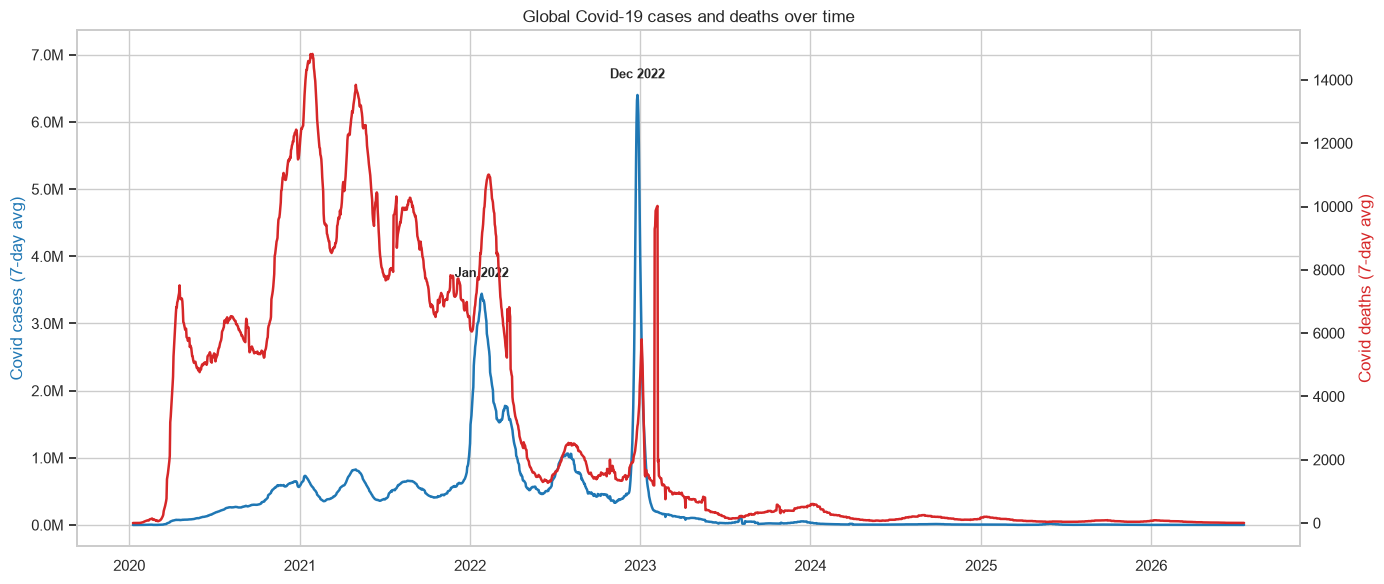

In [23]:
def axis_millions(ax, axis="x"):
    fmt = mtick.FuncFormatter(lambda v, _: f"{v / 1e6:,.1f}M")
    (ax.xaxis if axis == "x" else ax.yaxis).set_major_formatter(fmt)
def save_fig(name):
    # Save the current figure to outputs/figures and display it.
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

def lagged_corr_table(frame, x_col, y_col, lags, diff_window=None, min_obs=180):
    # For each country, correlate x(t) with y(t + lag). If diff_window is set, both series are
    # first converted to changes over that many days, which removes shared long-run trends.
    out = {}
    for code, g in frame.groupby("code"):
        g = g.set_index("date")
        x = g[x_col] if diff_window is None else g[x_col].diff(diff_window)
        y = g[y_col] if diff_window is None else g[y_col].diff(diff_window)
        row = {}
        for lag in lags:
            pair = pd.concat([x, y.shift(-lag)], axis=1).dropna()
            row[lag] = pair.iloc[:, 0].corr(pair.iloc[:, 1]) if len(pair) >= min_obs else np.nan
        out[code] = row
    return pd.DataFrame(out).T

global_daily = covid.groupby("date")[["new_cases_smoothed", "new_deaths_smoothed"]].sum(min_count=1)
cases_series = global_daily["new_cases_smoothed"].fillna(0)

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(global_daily.index, global_daily["new_cases_smoothed"], color="tab:blue", lw=1.8, label="Covid cases")
ax1.set_ylabel("Covid cases (7-day avg)", color="tab:blue")
axis_millions(ax1, "y")

ax2 = ax1.twinx()
ax2.plot(global_daily.index, global_daily["new_deaths_smoothed"], color="tab:red", lw=1.8, label="Covid deaths")
ax2.set_ylabel("Covid deaths (7-day avg)", color="tab:red")
ax2.grid(False)

peaks, _ = find_peaks(cases_series.values, distance=90, prominence=cases_series.max() * 0.1)
for i in peaks:
    ax1.annotate(cases_series.index[i].strftime("%b %Y"), (cases_series.index[i], cases_series.iloc[i]),
                 xytext=(0, 12), textcoords="offset points", ha="center", fontsize=9, fontweight="bold")

ax1.set_ylim(top=cases_series.max() * 1.15)   # headroom for peak labels
ax1.set_title("Global Covid-19 cases and deaths over time")
save_fig("q04_global_waves")

#### iii.Countries that recorded the highest total COVID-19 cases

,country,date,total_cases
529030,United States,2026-07-19,103436829.0
93132,China,2026-07-19,99381761.0
229861,India,2026-07-19,45056221.0
163632,France,2026-07-19,39060935.0
127754,Germany,2026-07-19,38437953.0
71604,Brazil,2026-07-19,38042729.0
270519,South Korea,2026-07-19,34571873.0
253778,Japan,2026-07-19,33803572.0
244213,Italy,2026-07-19,26969918.0
173197,United Kingdom,2026-07-19,25118508.0


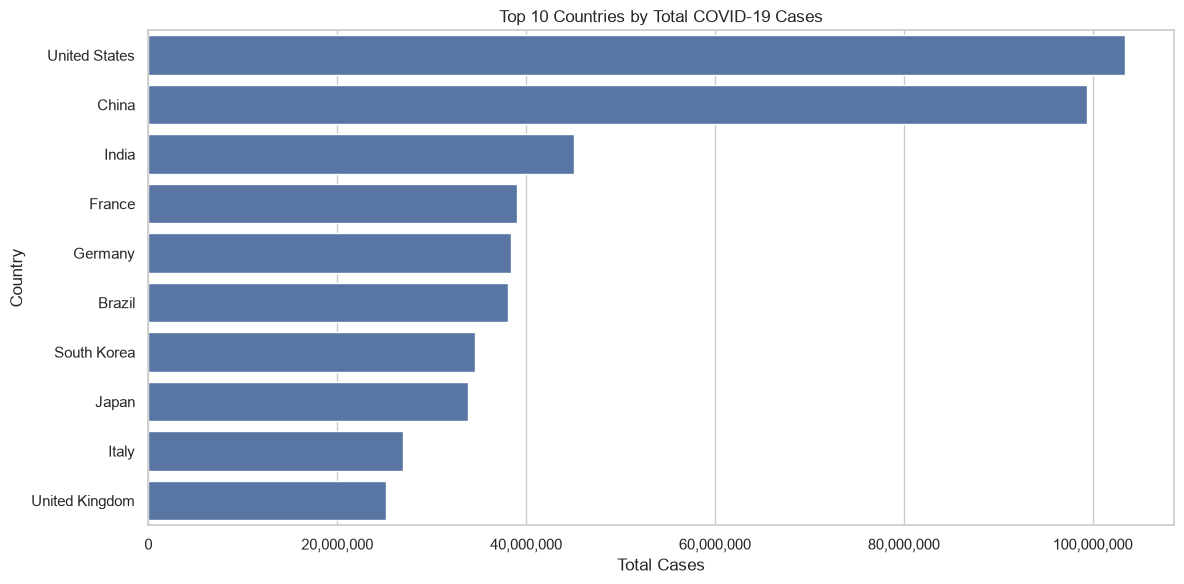

In [6]:
top_10_cases = (
    latest_cases
    .sort_values("total_cases", ascending=False)
    [["country", "date", "total_cases"]]
    .head(10)
)

display(top_10_cases)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=top_10_cases,
    x="total_cases",
    y="country"
)

# Display full numbers with commas
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)

plt.title("Top 10 Countries by Total COVID-19 Cases")
plt.xlabel("Total Cases")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

#### iv.African countries that recorded the highest total COVID-19 cases

,country,date,total_cases
198,South Africa,2026-07-19,4073188.0
142,Morocco,2026-07-19,1279115.0
217,Tunisia,2026-07-19,1153361.0
61,Egypt,2026-07-19,516023.0
119,Libya,2026-07-19,507269.0
67,Ethiopia,2026-07-19,501339.0
173,Reunion,2026-07-19,494595.0
237,Zambia,2026-07-19,349892.0
109,Kenya,2026-07-19,344162.0
133,Mauritius,2026-07-19,332300.0


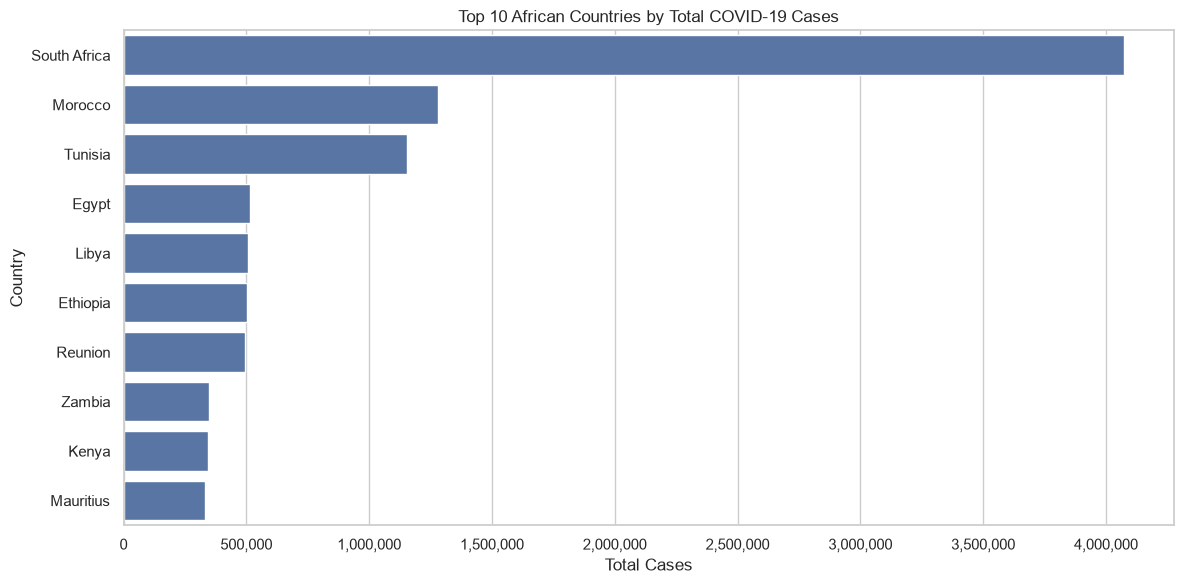

In [7]:

latest_cases = (
    covid
    .sort_values("date")
    .groupby("country", as_index=False)
    .last()
)

# to filter Africa using the continent column
African_latest_cases = latest_cases[latest_cases["continent"] == "Africa"]

# Top 10 African countries by total cases
top_10_cases = (
    African_latest_cases
    .sort_values("total_cases", ascending=False)
    [["country", "date", "total_cases"]]
    .head(10)
)

display(top_10_cases)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=top_10_cases,
    x="total_cases",
    y="country"
)

# Display full numbers with commas
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)

plt.title("Top 10 African Countries by Total COVID-19 Cases")
plt.xlabel("Total Cases")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

#### v.European Countries that recorded the highest total COVID-19 cases

,country,date,total_cases
72,France,2026-07-19,39060935.0
78,Germany,2026-07-19,38437953.0
103,Italy,2026-07-19,26969918.0
225,United Kingdom,2026-07-19,25118508.0
175,Russia,2026-07-19,24901467.0
201,Spain,2026-07-19,13980340.0
148,Netherlands,2026-07-19,8657553.0
169,Poland,2026-07-19,6843822.0
12,Austria,2026-07-19,6083792.0
81,Greece,2026-07-19,5867249.0


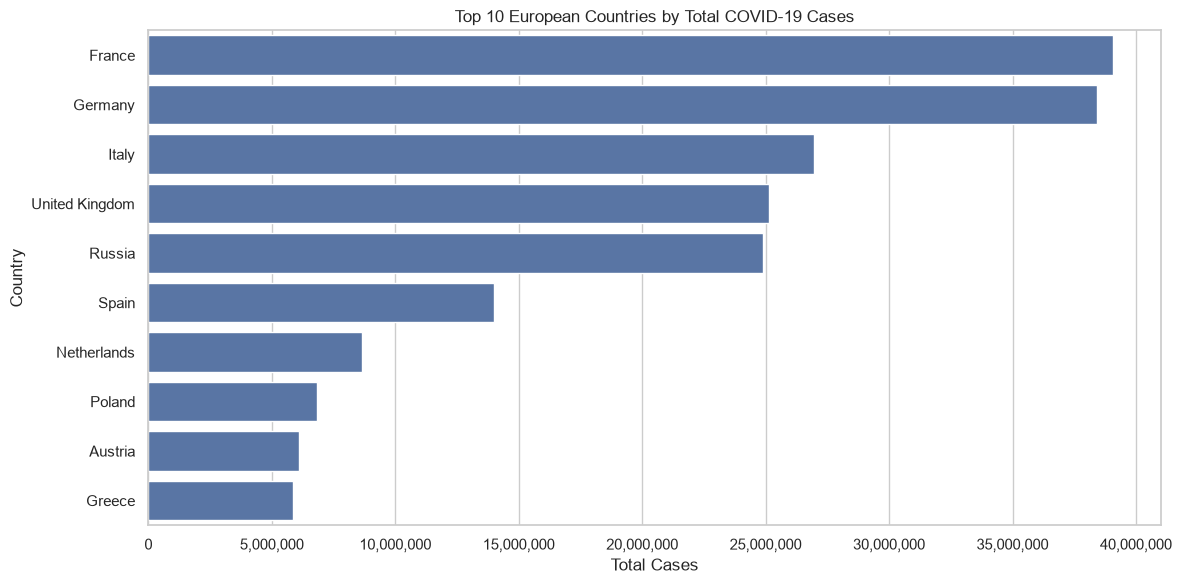

In [8]:

latest_cases = (
    covid
    .sort_values("date")
    .groupby("country", as_index=False)
    .last()
)

# To filter Europe using the continent column
european_latest_cases = latest_cases[latest_cases["continent"] == "Europe"]

# Top 10 European countries by total cases
top_10_cases = (
    european_latest_cases
    .sort_values("total_cases", ascending=False)
    [["country", "date", "total_cases"]]
    .head(10)
)

display(top_10_cases)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=top_10_cases,
    x="total_cases",
    y="country"
)

# Display full numbers with commas
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)

plt.title("Top 10 European Countries by Total COVID-19 Cases")
plt.xlabel("Total Cases")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

#### vi.Asian Countries that recorded the highest total COVID-19 cases

,country,date,total_cases
42,China,2026-07-19,99381761.0
96,India,2026-07-19,45056221.0
199,South Korea,2026-07-19,34571873.0
105,Japan,2026-07-19,33803572.0
218,Turkey,2026-07-19,17004726.0
233,Vietnam,2026-07-19,11624000.0
98,Iran,2026-07-19,7627863.0
97,Indonesia,2026-07-19,6830274.0
211,Thailand,2026-07-19,5450663.0
126,Malaysia,2026-07-19,5329836.0


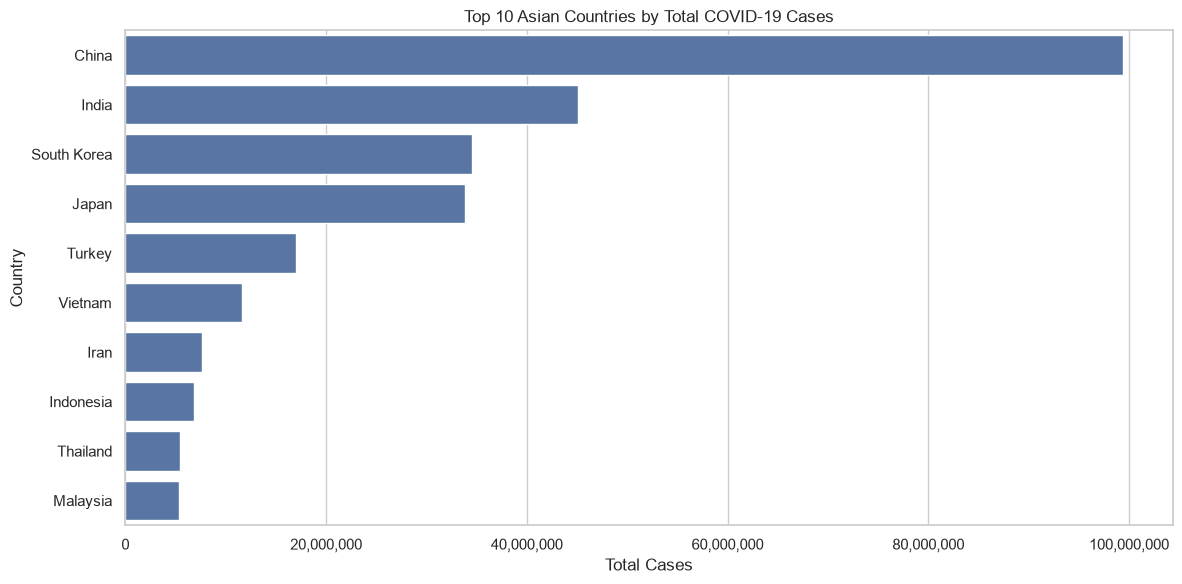

In [9]:
latest_cases = (
    covid
    .sort_values("date")
    .groupby("country", as_index=False)
    .last()
)

# To filter Asia using the continent column
Asian_latest_cases = latest_cases[latest_cases["continent"] == "Asia"]

# Top 10 Asian countries by total cases
top_10_cases = (
    Asian_latest_cases
    .sort_values("total_cases", ascending=False)
    [["country", "date", "total_cases"]]
    .head(10)
)

display(top_10_cases)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=top_10_cases,
    x="total_cases",
    y="country"
)

# Display full numbers with commas
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)

plt.title("Top 10 Asian Countries by Total COVID-19 Cases")
plt.xlabel("Total Cases")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

#### vii. 10 countries had the highest case fatality ratio

,country,date,total_cases,total_deaths,CFR
555327,Yemen,2026-07-19,11945.0,2159.0,18.074508
436769,Sudan,2026-07-19,63993.0,5046.0,7.885237
484597,Syria,2026-07-19,57423.0,3163.0,5.508246
455902,Somalia,2026-07-19,27334.0,1361.0,4.979147
396117,Peru,2026-07-19,4533838.0,221072.0,4.876045
144498,Egypt,2026-07-19,516023.0,24830.0,4.811801
317166,Mexico,2026-07-19,7630870.0,335111.0,4.391518
57255,Bosnia and Herzegovina,2026-07-19,404289.0,16419.0,4.061204
280087,Liberia,2026-07-19,7932.0,294.0,3.706505
4783,Afghanistan,2026-07-19,235214.0,7998.0,3.400308


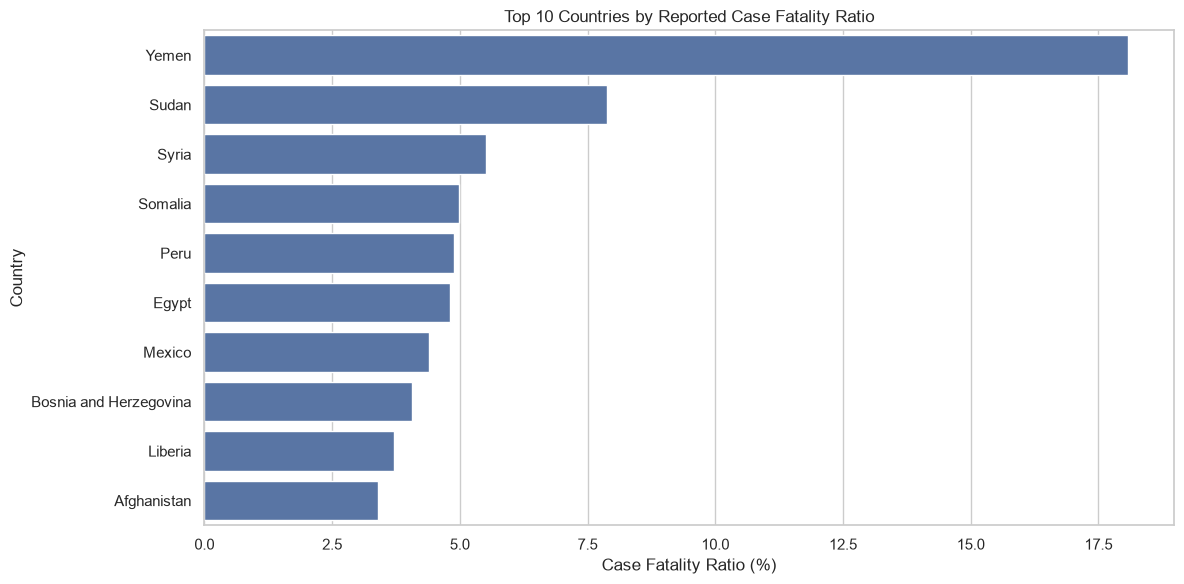

In [10]:
latest_cfr = (
    covid.dropna(subset=["total_cases", "total_deaths"])
    .groupby("code", as_index=False)
    .tail(1)
    .copy()
)

latest_cfr = latest_cfr[
    latest_cfr["total_cases"] > 0
].copy()

latest_cfr["CFR"] = (
    latest_cfr["total_deaths"] /
    latest_cfr["total_cases"]
) * 100

top_10_cfr = (
    latest_cfr
    .sort_values("CFR", ascending=False)
    [["country", "date", "total_cases", "total_deaths", "CFR"]]
    .head(10)
)

display(top_10_cfr)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_cfr, x="CFR", y="country")
plt.title("Top 10 Countries by Reported Case Fatality Ratio")
plt.xlabel("Case Fatality Ratio (%)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

#### viii.Each continent experience its peak wave

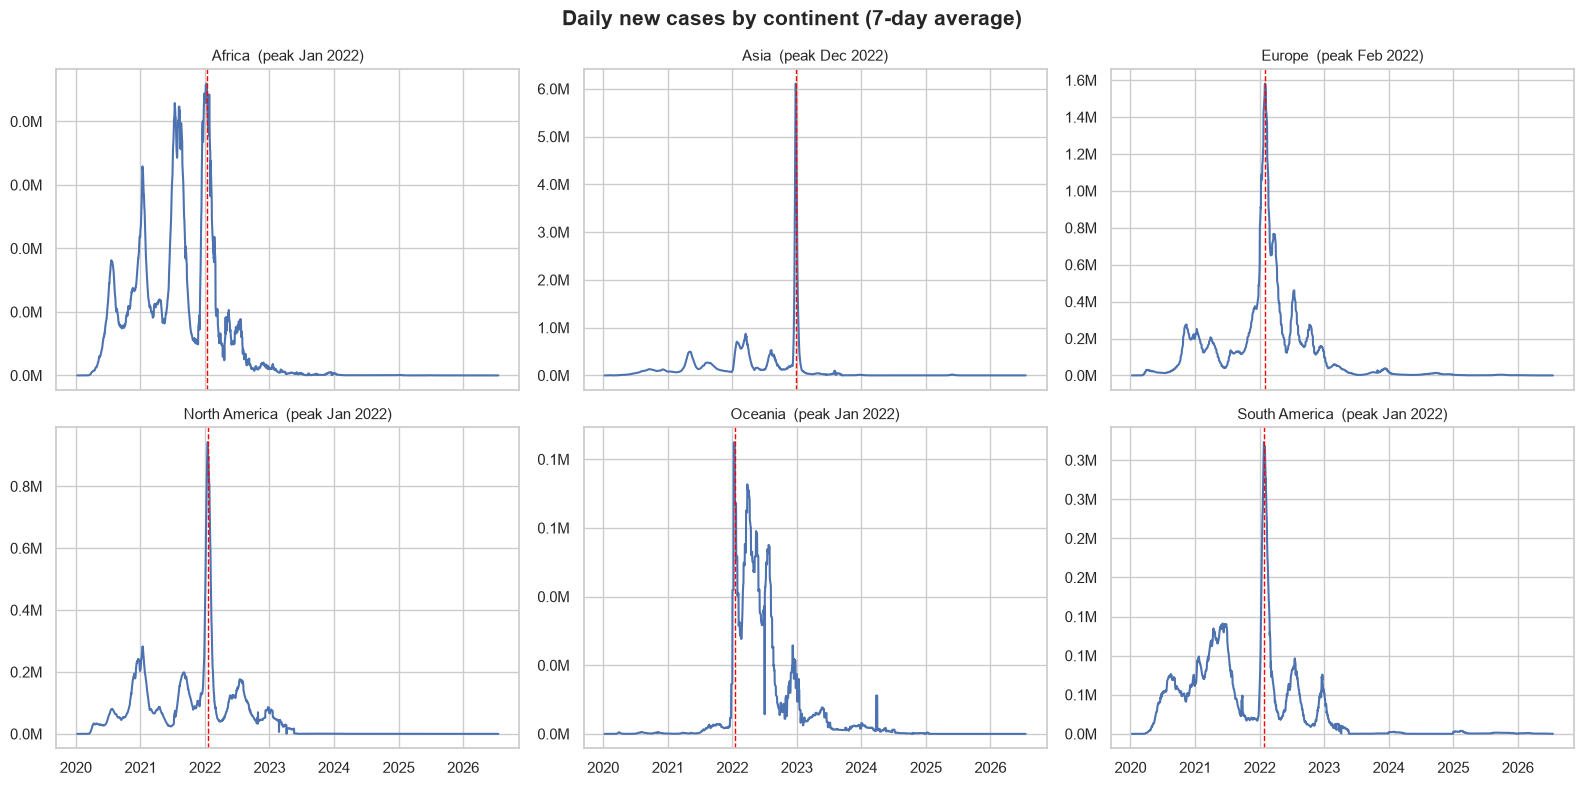

,peak_date,new_cases_smoothed
continent,,
Africa,2022-01-10,45959.0
Asia,2022-12-26,6109825.0
Europe,2022-02-01,1581436.0
North America,2022-01-17,942798.0
Oceania,2022-01-14,85021.0
South America,2022-01-25,373116.0


In [13]:
cont_daily = (
    countries.dropna(subset=["continent"])
    .groupby(["continent", "date"])["new_cases_smoothed"].sum(min_count=1)
    .reset_index()
)
cont_peaks = (
    cont_daily.dropna(subset=["new_cases_smoothed"])
    .loc[lambda d: d.groupby("continent")["new_cases_smoothed"].idxmax()]
    .set_index("continent")
)

conts = sorted(cont_daily["continent"].unique())
ncols = 3
nrows = int(np.ceil(len(conts) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), sharex=True)
for ax, cont in zip(np.ravel(axes), conts):
    d = cont_daily[cont_daily["continent"] == cont]
    ax.plot(d["date"], d["new_cases_smoothed"], lw=1.5)
    peak_date = cont_peaks.loc[cont, "date"]
    ax.axvline(peak_date, color="red", ls="--", lw=1)
    ax.set_title(f"{cont}  (peak {peak_date:%b %Y})", fontsize=11)
    axis_millions(ax, "y")
for ax in np.ravel(axes)[len(conts):]:
    ax.set_visible(False)
fig.suptitle("Daily new cases by continent (7-day average)", fontsize=15, fontweight="bold")
save_fig("q05_continent_peaks")
display(cont_peaks[["date", "new_cases_smoothed"]].rename(columns={"date": "peak_date"}).round({"new_cases_smoothed": 0}))

### Section B: Government Response and Policy (Q6-Q8)

#### i. Did stricter lockdowns (stringency index) reduce the number of new cases in South Africa,US,UK,India,Brazil and Germany

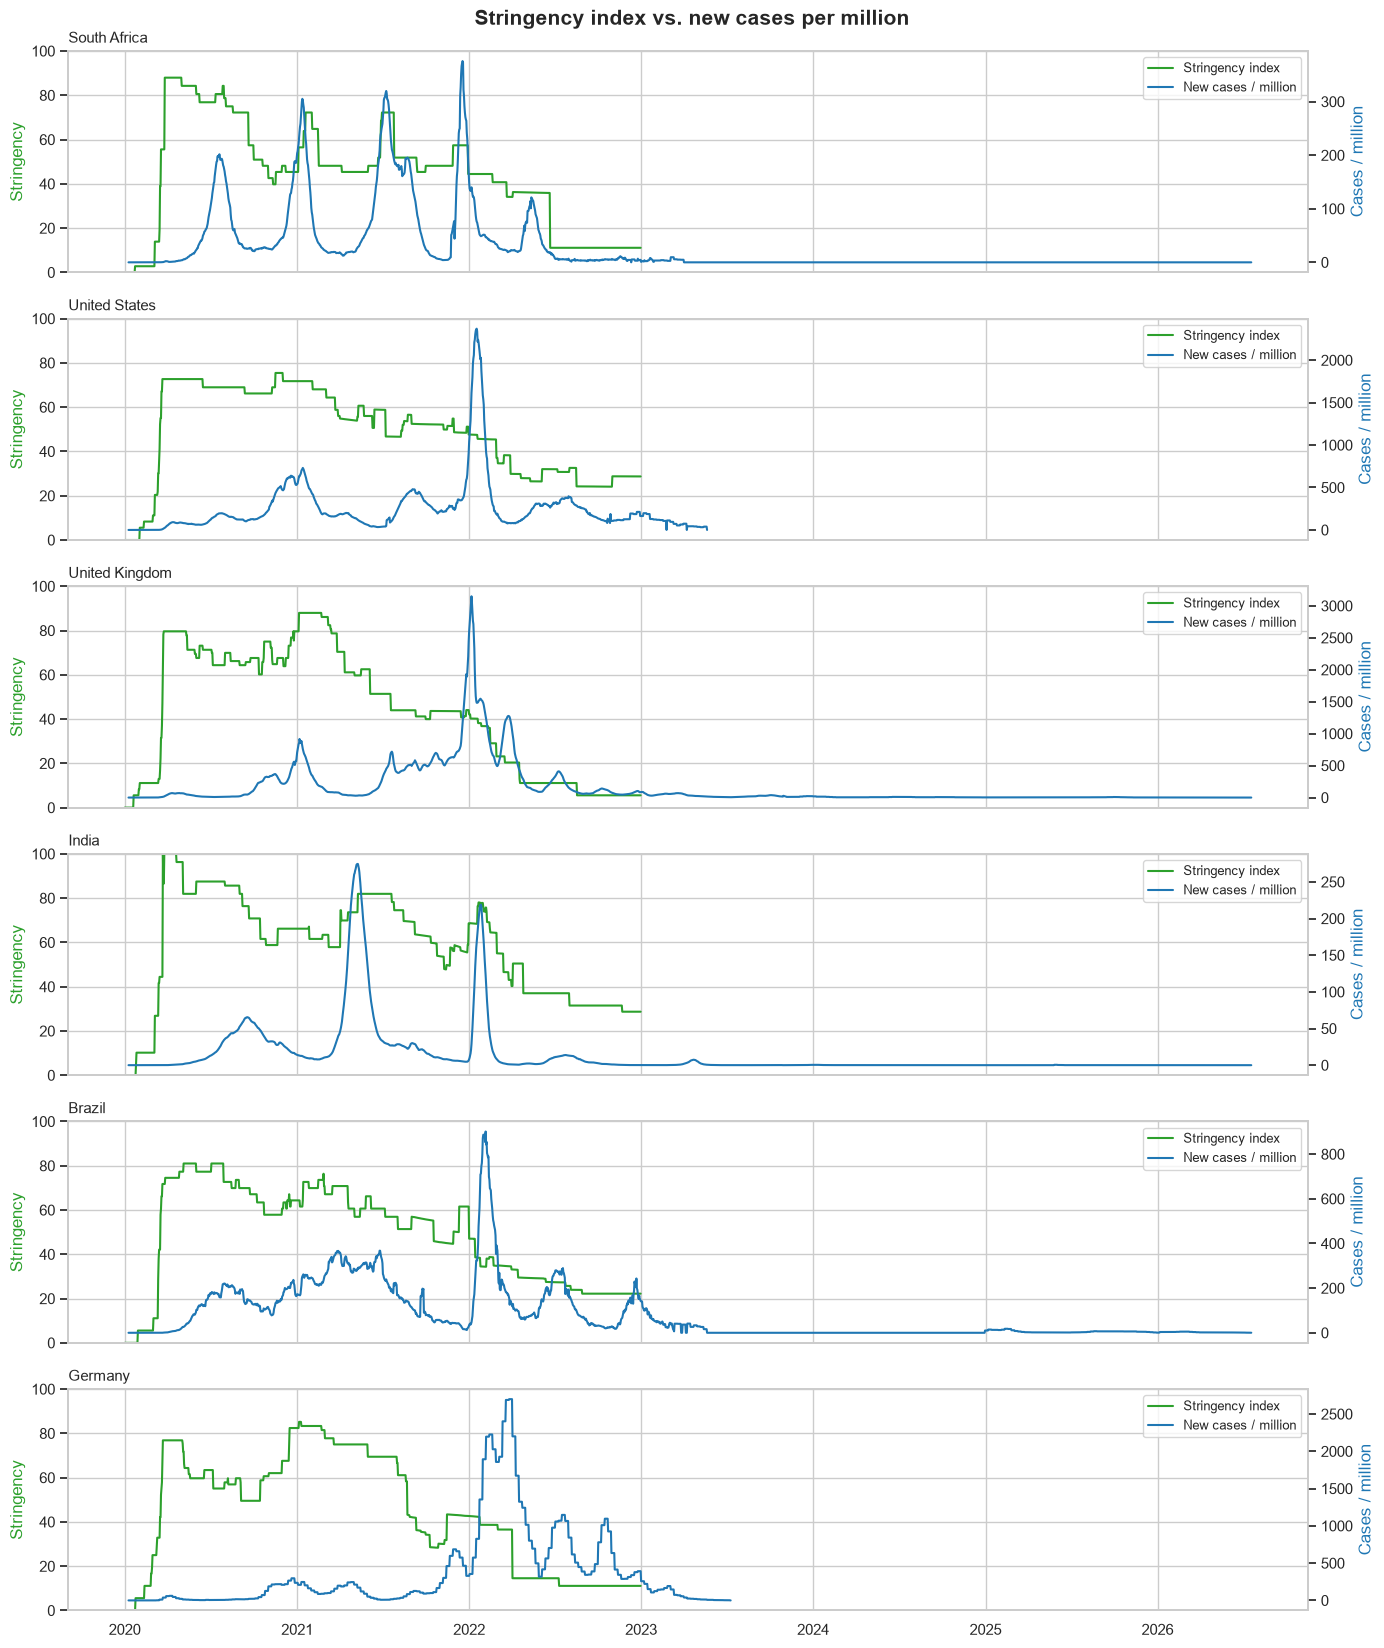

In [18]:
FOCUS = [c for c in ["ZAF", "USA", "GBR", "IND", "BRA", "DEU"] if c in latest.index]

fig, axes = plt.subplots(len(FOCUS), 1, figsize=(14, 2.8 * len(FOCUS)), sharex=True)
for ax, code in zip(np.atleast_1d(axes), FOCUS):
    g = countries[countries["code"] == code]
    ax.plot(g["date"], g["stringency_index"], color="tab:green", lw=1.5, label="Stringency index")
    ax.set_ylabel("Stringency", color="tab:green")
    ax.set_ylim(0, 100)
    ax_r = ax.twinx()
    ax_r.plot(g["date"], g["new_cases_pm"], color="tab:blue", lw=1.5, label="New cases / million")
    ax_r.set_ylabel("Cases / million", color="tab:blue")
    ax_r.grid(False)
    ax.set_title(latest.loc[code, "country"], loc="left", fontsize=11)

    # combined legend from both axes
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax_r.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=9)

fig.suptitle("Stringency index vs. new cases per million", fontsize=15, fontweight="bold")
save_fig("q06_stringency_vs_cases")

#### ii.Testing the relationship statistically for every country, correlate the 14-day change in stringency with the 14-day change in cases a few weeks later (0, 7, 14, 21, 28 days). A negative correlation at longer lags would be consistent with restrictions working, though governments also tighten rules because cases are rising

C:\ProgramData\anaconda3\envs\ALX_Python\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\ProgramData\anaconda3\envs\ALX_Python\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


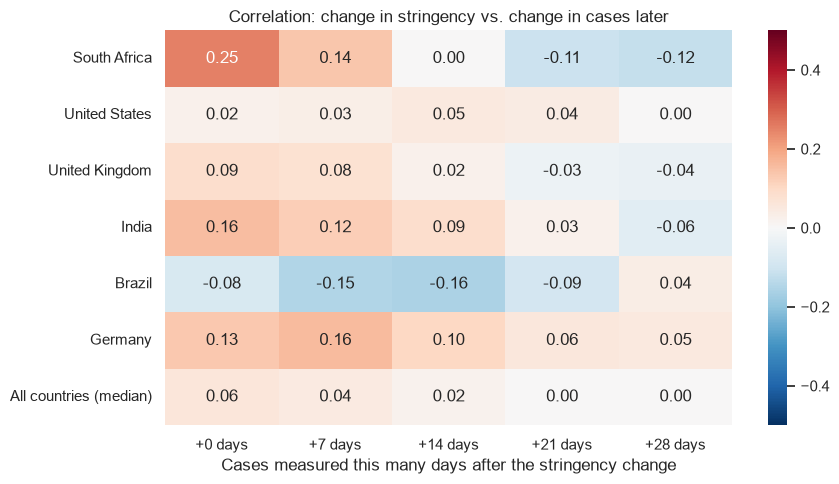

In [26]:
LAGS = [0, 7, 14, 21, 28]
lag_cases = lagged_corr_table(countries, "stringency_index", "new_cases_pm", LAGS, diff_window=14)

heat = pd.concat([
    lag_cases.loc[FOCUS].rename(index=latest["country"]),
    lag_cases.median().to_frame("All countries (median)").T,
])
heat.columns = [f"+{c} days" for c in heat.columns]

plt.figure(figsize=(9, 5))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.5, vmax=0.5)
plt.title("Correlation: change in stringency vs. change in cases later")
plt.xlabel("Cases measured this many days after the stringency change")
save_fig("q06_lag_correlation")

#### iii.How did the reproduction rate change over time

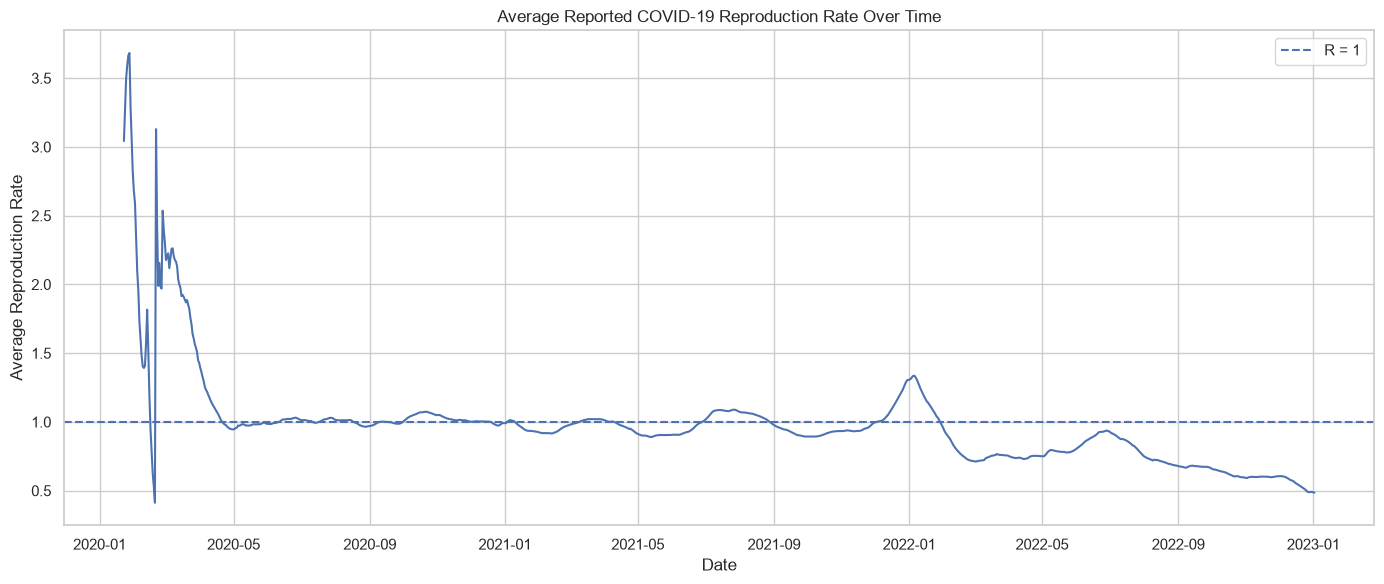

In [28]:
r_trend = (
    covid.dropna(subset=["reproduction_rate"])
    .groupby("date", as_index=False)["reproduction_rate"]
    .mean()
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=r_trend, x="date", y="reproduction_rate")
plt.axhline(1, linestyle="--", label="R = 1")
plt.title("Average Reported COVID-19 Reproduction Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Average Reproduction Rate")
plt.legend()
plt.tight_layout()
plt.show()

### Section C: Vaccination Impact

#### i.How quickly did vaccination rollouts progress across countries

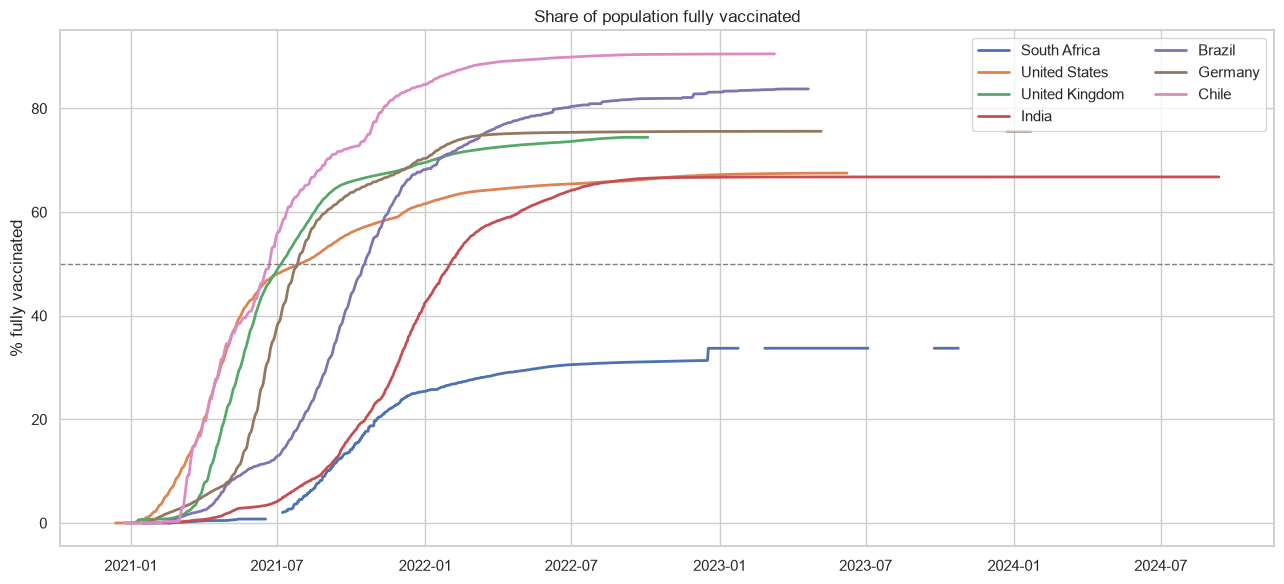

134 of 239 countries reached 50% fully vaccinated
Median days from first vaccination to 50%: 232


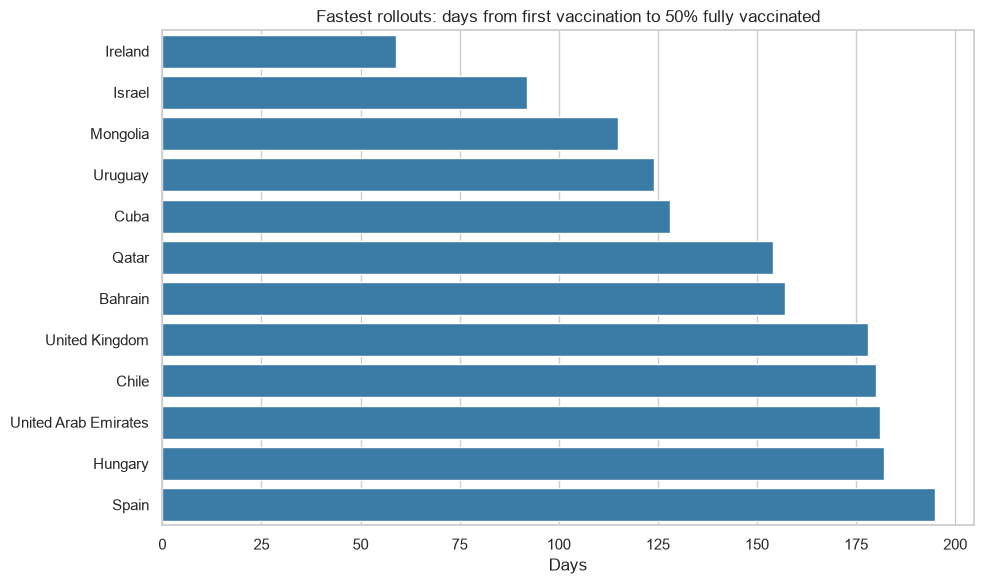

In [30]:
ROLLOUT = [c for c in ["ZAF", "USA", "GBR", "IND", "BRA", "DEU", "CHL"] if c in latest.index]

plt.figure(figsize=(13, 6))
for code in ROLLOUT:
    g = countries[countries["code"] == code]
    plt.plot(g["date"], g["vacc_pct_ff"], lw=2, label=latest.loc[code, "country"])
plt.axhline(50, color="grey", ls="--", lw=1)
plt.title("Share of population fully vaccinated")
plt.ylabel("% fully vaccinated")
plt.legend(ncol=2)
save_fig("q09_vaccination_rollout")

rows = []
for code, g in countries.groupby("code"):
    start = g.loc[g["total_vaccinations"] > 0, "date"].min()
    d50 = g.loc[g["vacc_pct_ff"] >= 50, "date"].min()
    rows.append({"code": code, "first_vacc_date": start, "date_50pct": d50})

rollout = pd.DataFrame(rows).set_index("code").join(latest[["country", "population"]])
rollout["days_to_50pct"] = (rollout["date_50pct"] - rollout["first_vacc_date"]).dt.days
reached = rollout.dropna(subset=["days_to_50pct"])

print(f"{len(reached)} of {len(rollout)} countries reached 50% fully vaccinated")
print(f"Median days from first vaccination to 50%: {reached['days_to_50pct'].median():.0f}")

fastest = reached[reached["population"] >= MIN_POP].nsmallest(12, "days_to_50pct")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=fastest, y="country", x="days_to_50pct", color="#2980b9")
ax.set_title("Fastest rollouts: days from first vaccination to 50% fully vaccinated")
ax.set_xlabel("Days")
ax.set_ylabel("")
save_fig("q09_fastest_rollouts")

#### ii How did the reported vaccinations change globally over time

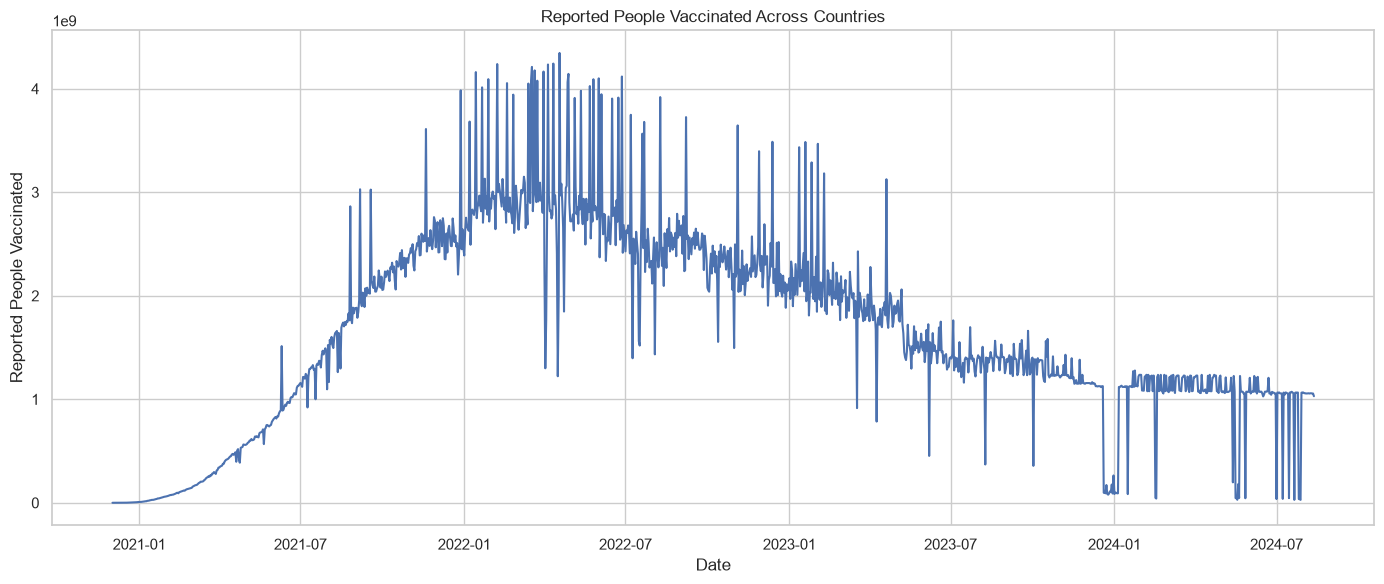

In [35]:
global_vaccination = (
    covid.dropna(subset=["people_vaccinated"])
    .groupby("date", as_index=False)["people_vaccinated"]
    .sum()
)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=global_vaccination,
    x="date",
    y="people_vaccinated"
)
plt.title("Reported People Vaccinated Across Countries")
plt.xlabel("Date")
plt.ylabel("Reported People Vaccinated")
plt.tight_layout()
plt.show()

#### iii.Countries reported the highest number of people vaccinated

,country,date,people_vaccinated
91946,China,2023-04-20,1.318027e+09
229155,India,2024-08-12,1.027439e+09
527863,United States,2023-05-09,2.702272e+08
224111,Indonesia,2023-11-23,2.044194e+08
70389,Brazil,2023-03-22,1.896434e+08
387966,Pakistan,2023-11-14,1.655679e+08
46930,Bangladesh,2024-06-22,1.515072e+08
252847,Japan,2023-12-31,1.047401e+08
315785,Mexico,2022-10-07,9.717950e+07
363995,Nigeria,2023-11-05,9.382943e+07


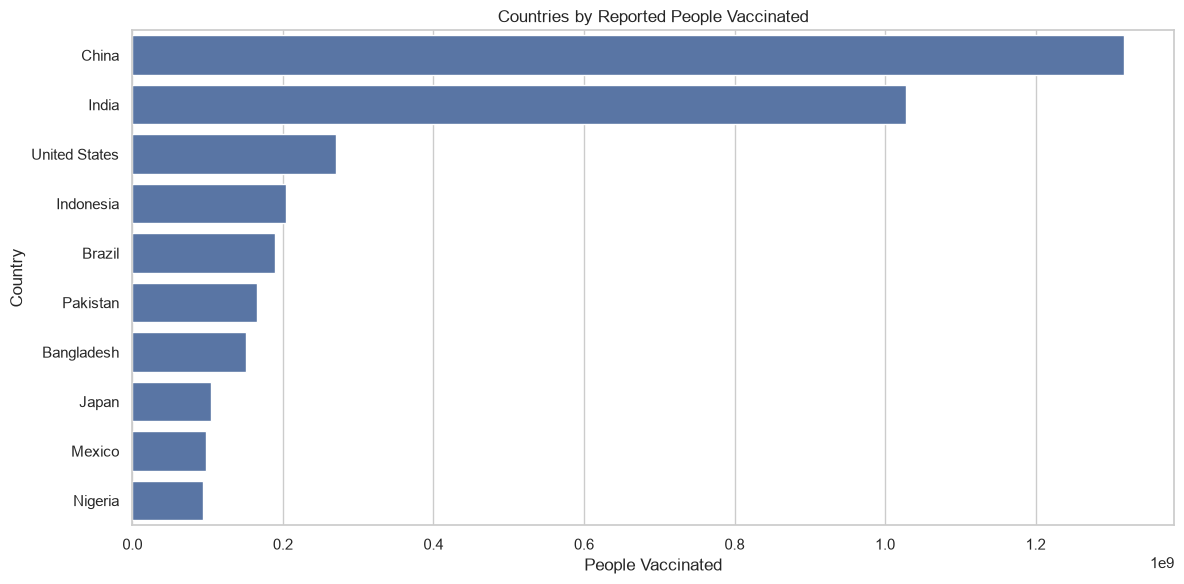

In [38]:
latest_vaccinated = (
    covid.dropna(subset=["people_vaccinated"])
    .groupby("code", as_index=False)
    .tail(1)
    .copy()
)

top_10_vaccinated = (
    latest_vaccinated
    .sort_values("people_vaccinated", ascending=False)
    [["country", "date", "people_vaccinated"]]
    .head(10)
)

display(top_10_vaccinated)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_10_vaccinated,
    x="people_vaccinated",
    y="country"
)
plt.title("Countries by Reported People Vaccinated")
plt.xlabel("People Vaccinated")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

#### iv. Did higher vaccination rates reduce the death rate

In [41]:
def before_after_cfr(frame, threshold, window=90, min_cases=1000):
    rows = []
    for code, g in frame.groupby("code"):
        reached_dates = g.loc[g["vacc_pct_ff"] >= threshold, "date"]
        if reached_dates.empty:
            continue
        d0 = reached_dates.min()
        before = g[(g["date"] >= d0 - pd.Timedelta(days=window)) & (g["date"] < d0)]
        after = g[(g["date"] >= d0) & (g["date"] < d0 + pd.Timedelta(days=window))]
        if min(before["new_cases_smoothed"].notna().sum(), after["new_cases_smoothed"].notna().sum()) < 0.8 * window:
            continue
        cases_b, deaths_b = before["new_cases_smoothed"].sum(), before["new_deaths_smoothed"].sum()
        cases_a, deaths_a = after["new_cases_smoothed"].sum(), after["new_deaths_smoothed"].sum()
        if min(cases_b, cases_a) < min_cases:
            continue
        rows.append({"code": code, "milestone_date": d0,
                     "cfr_before": deaths_b / cases_b * 100, "cfr_after": deaths_a / cases_a * 100})
    return pd.DataFrame(rows)


results, summary = {}, []
for threshold in (30, 50):
    res = before_after_cfr(countries, threshold)
    if len(res) < 5:
        print(f"{threshold}% milestone: too few countries ({len(res)}) for a test")
        continue
    results[threshold] = res
    t_stat, t_p = stats.ttest_rel(res["cfr_before"], res["cfr_after"])
    w_p = stats.wilcoxon(res["cfr_before"], res["cfr_after"]).pvalue
    summary.append({
        "milestone": f"{threshold}% fully vaccinated", "countries": len(res),
        "mean_cfr_before_%": res["cfr_before"].mean(), "mean_cfr_after_%": res["cfr_after"].mean(),
        "t_stat": t_stat, "t_test_p": t_p, "wilcoxon_p": w_p,
    })
display(pd.DataFrame(summary).round(4))

,milestone,countries,mean_cfr_before_%,mean_cfr_after_%,t_stat,t_test_p,wilcoxon_p
0,30% fully vaccinated,126,1.7661,1.3376,2.3494,0.0204,0.0045
1,50% fully vaccinated,96,1.3921,0.9877,2.2624,0.0260,0.0446


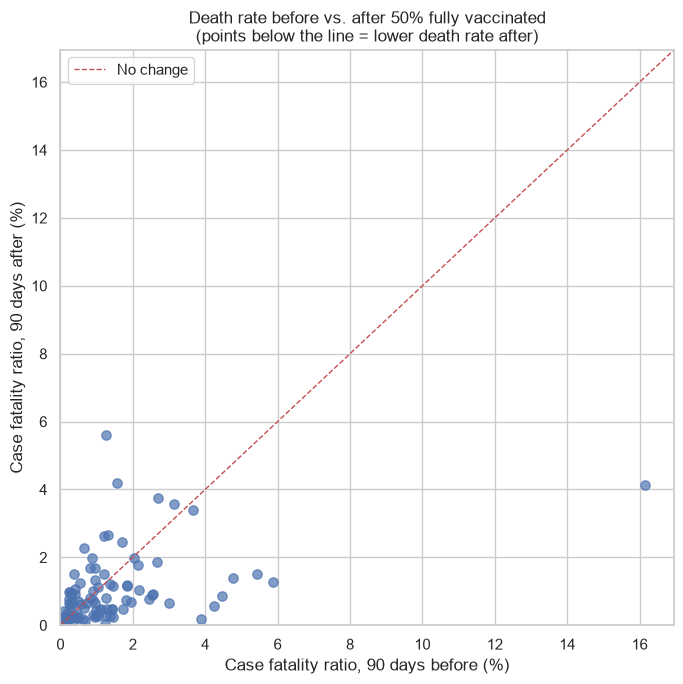

In [42]:
if 50 in results:
    res = results[50]
    lim = max(res["cfr_before"].max(), res["cfr_after"].max()) * 1.05
    plt.figure(figsize=(7, 7))
    plt.scatter(res["cfr_before"], res["cfr_after"], alpha=0.7, s=45)
    plt.plot([0, lim], [0, lim], "r--", lw=1, label="No change")
    plt.xlim(0, lim); plt.ylim(0, lim)
    plt.xlabel("Case fatality ratio, 90 days before (%)")
    plt.ylabel("Case fatality ratio, 90 days after (%)")
    plt.title("Death rate before vs. after 50% fully vaccinated\n(points below the line = lower death rate after)")
    plt.legend()
    save_fig("q10_cfr_before_after")

#### v.Monthly new vaccinations vary by continent

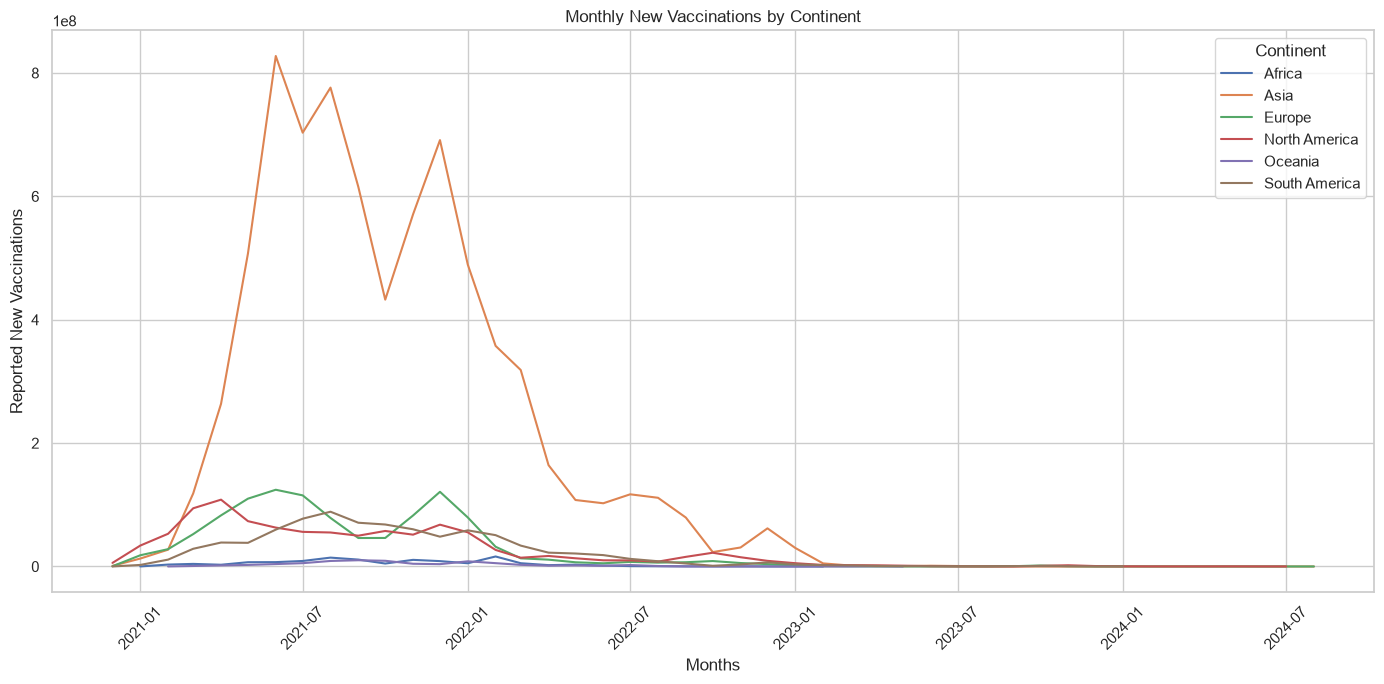

In [52]:
monthly_vaccinations = covid.dropna(
    subset=["continent", "new_vaccinations"]
).copy()

monthly_vaccinations["month"] = (
    monthly_vaccinations["date"].dt.to_period("M").dt.to_timestamp()
)

monthly_vaccinations = (
    monthly_vaccinations
    .groupby(["continent", "month"], as_index=False)["new_vaccinations"]
    .sum()
)

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=monthly_vaccinations,
    x="month",
    y="new_vaccinations",
    hue="continent"
)
plt.title("Monthly New Vaccinations by Continent")
plt.xlabel("Months")
plt.ylabel("Reported New Vaccinations")
plt.xticks(rotation=45)
plt.legend(title="Continent")
plt.tight_layout()
plt.show()

### Section D: Hospital Pressure

#### i.Countries recorded the highest ICU patient counts

,code,country,icu_patients
36,USA,United States,28891.0
0,ARG,Argentina,7969.0
17,FRA,France,7019.0
11,DEU,Germany,5761.0
14,ESP,Spain,4894.0
18,GBR,United Kingdom,4077.0
21,ITA,Italy,4068.0
8,CHL,Chile,3406.0
22,JPN,Japan,3034.0
37,ZAF,South Africa,2694.0


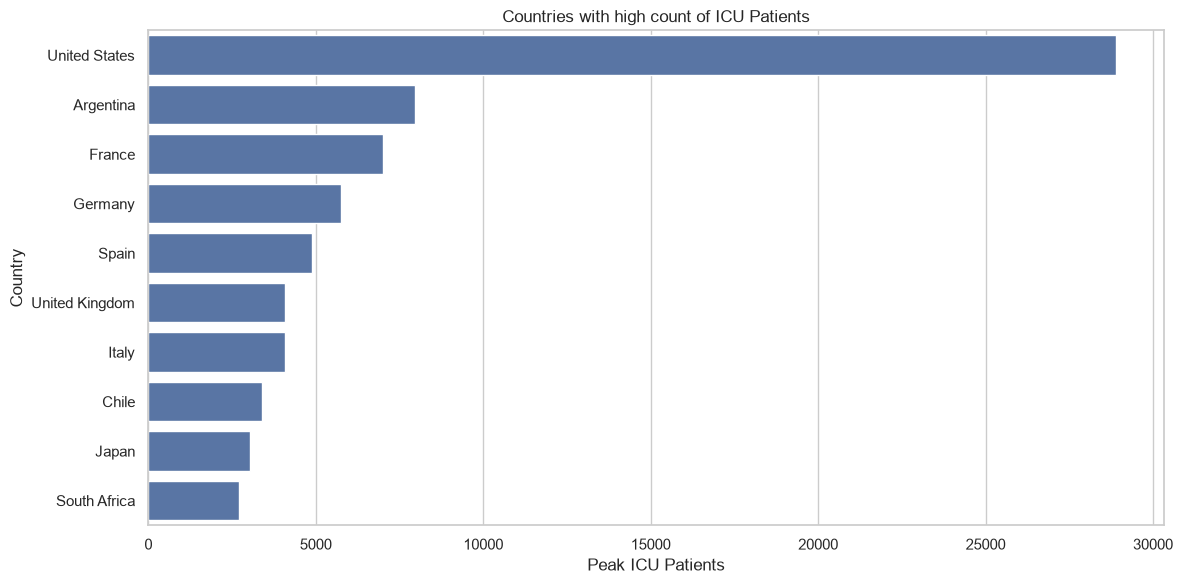

In [53]:
peak_icu = (
    covid.dropna(subset=["icu_patients"])
    .groupby(["code", "country"], as_index=False)["icu_patients"]
    .max()
    .sort_values("icu_patients", ascending=False)
    .head(10)
)

display(peak_icu)

plt.figure(figsize=(12, 6))
sns.barplot(data=peak_icu, x="icu_patients", y="country")
plt.title("Countries with high count of ICU Patients")
plt.xlabel("Peak ICU Patients")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

#### ii.Hospital and ICU patient numbers change over time

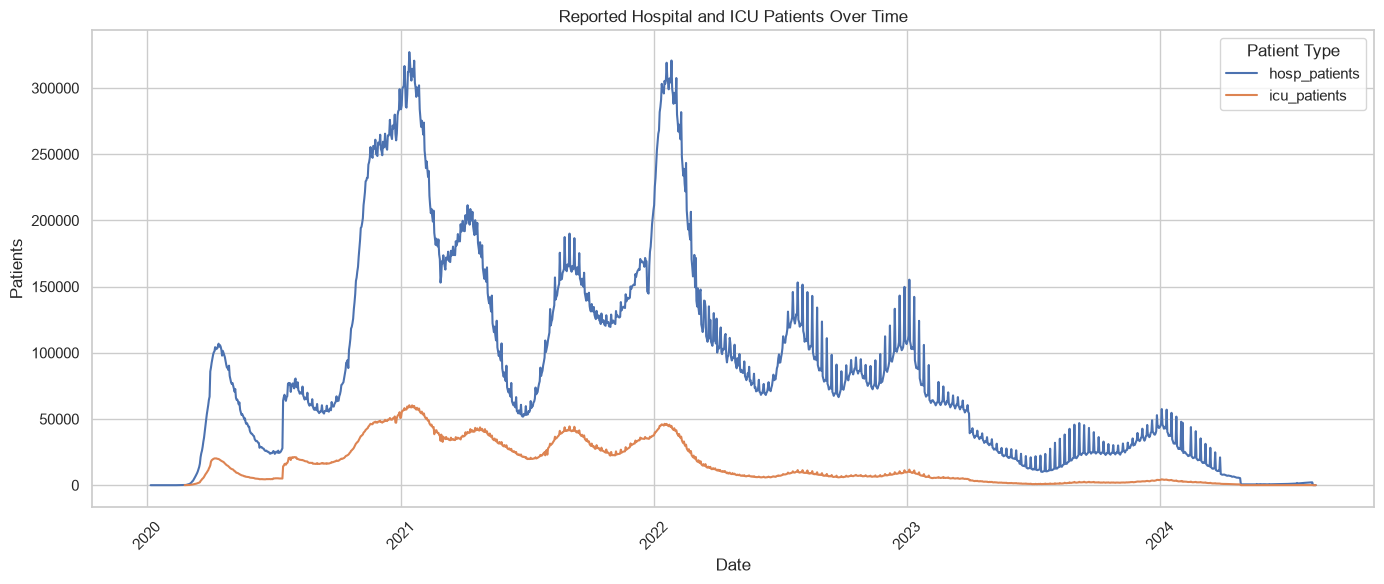

In [54]:
hospital_trend = (
    covid.groupby("date", as_index=False)
    [["hosp_patients", "icu_patients"]]
    .sum(min_count=1)
)

hospital_trend = hospital_trend.melt(
    id_vars="date",
    var_name="Patient Type",
    value_name="Patients"
)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=hospital_trend,
    x="date",
    y="Patients",
    hue="Patient Type"
)
plt.title("Reported Hospital and ICU Patients Over Time")
plt.xlabel("Date")
plt.ylabel("Patients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### iii.Did hospital admissions lead deaths? By how many days?
**Approach:** for each country with enough data, correlate weekly hospital admissions on day *t* with daily deaths on day *t + lag* for lags of 0-35 days. The lag with the highest correlation estimates how long deaths trail admissions.

20 countries with 180+ days of hospital admission data


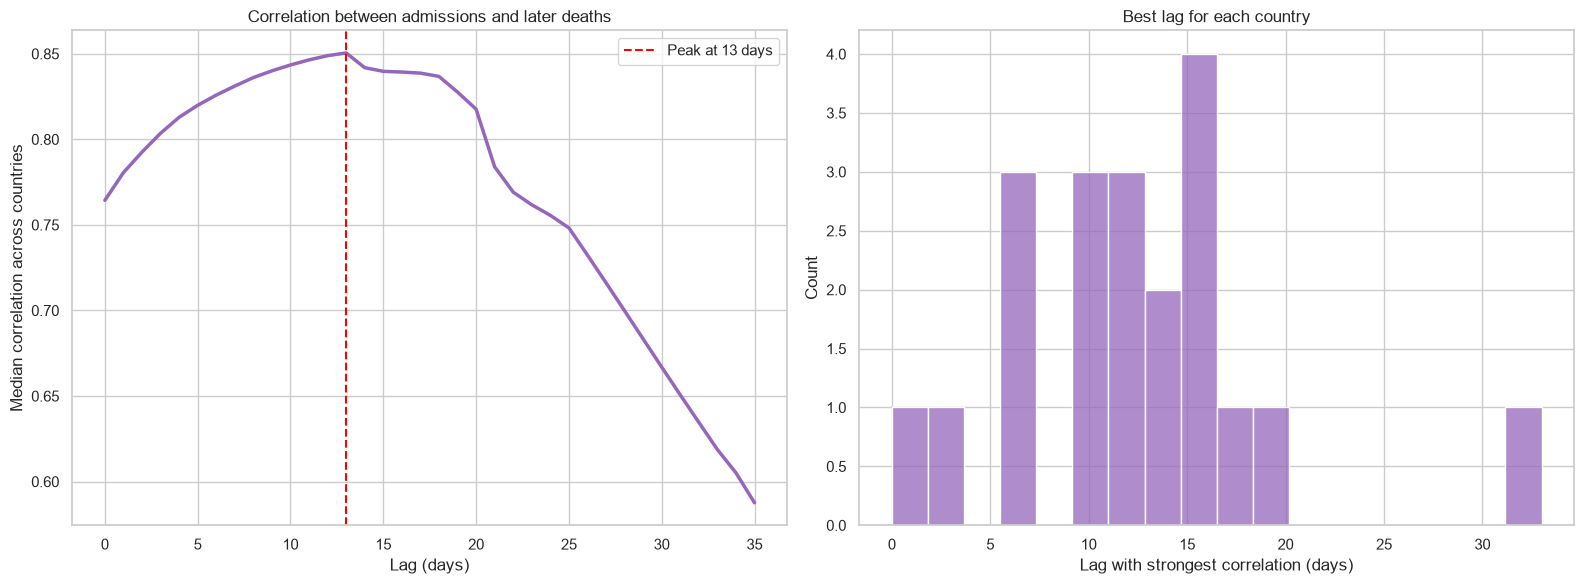

Median best lag across countries: 12 days


In [55]:
n_hosp = countries.groupby("code")["weekly_hosp_admissions"].count()
hosp_codes = n_hosp[n_hosp >= 180].index
print(f"{len(hosp_codes)} countries with 180+ days of hospital admission data")

lag_hosp = lagged_corr_table(
    countries[countries["code"].isin(hosp_codes)],
    "weekly_hosp_admissions", "new_deaths_smoothed", lags=range(0, 36), diff_window=None,
).dropna(how="all")

median_curve = lag_hosp.median()
best_lag = lag_hosp.idxmax(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(median_curve.index, median_curve.values, lw=2.5, color="tab:purple")
axes[0].axvline(median_curve.idxmax(), color="red", ls="--", label=f"Peak at {median_curve.idxmax()} days")
axes[0].set_title("Correlation between admissions and later deaths")
axes[0].set_xlabel("Lag (days)")
axes[0].set_ylabel("Median correlation across countries")
axes[0].legend()
sns.histplot(best_lag, bins=18, color="tab:purple", ax=axes[1])
axes[1].set_title("Best lag for each country")
axes[1].set_xlabel("Lag with strongest correlation (days)")
save_fig("q14_admissions_lead_deaths")
print(f"Median best lag across countries: {best_lag.median():.0f} days")

## iv.What share of cases required hospitalization over time?

**Approach:** divide weekly hospital admissions by weekly cases (`new_cases_smoothed × 7`) and track the monthly median across countries, shading the main variant periods. Days with fewer than 100 cases per week are excluded and ratios are capped at 100%. This is an approximation, since admissions lag cases and testing changed over time.

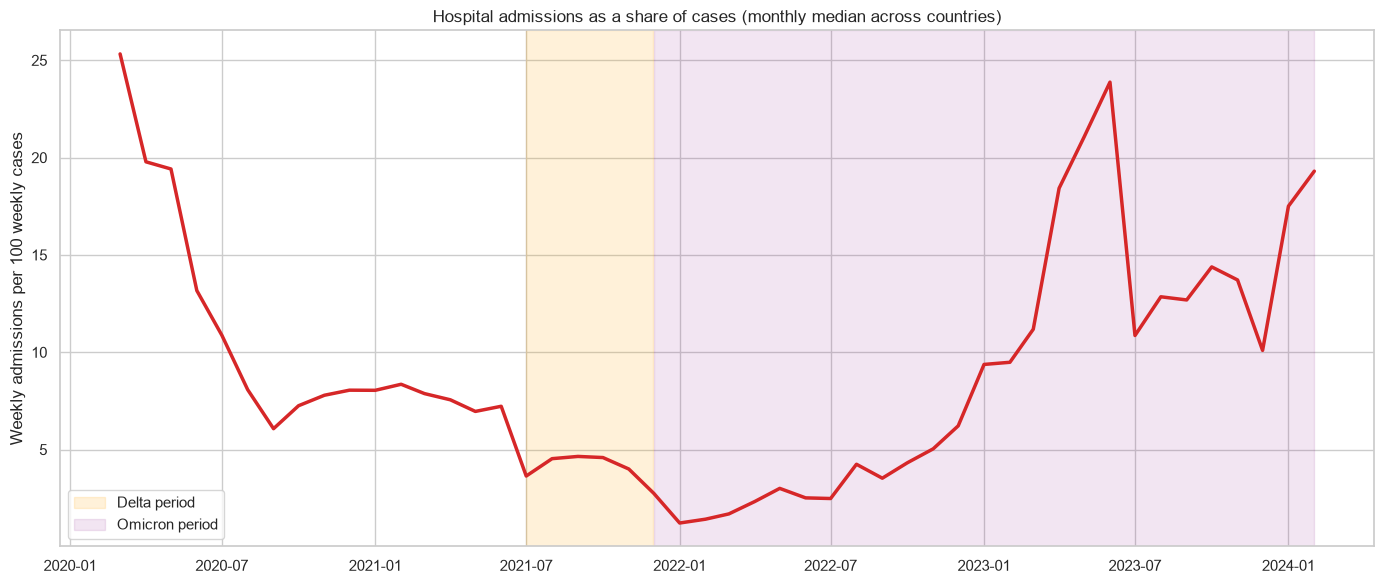

,median,mean,count
era,,,
Original/Alpha (to Jun 2021),8.62,12.88,6550
Delta (Jul-Nov 2021),4.35,5.27,2440
Omicron+ (Dec 2021 on),5.20,9.80,9707


In [56]:
h = countries.dropna(subset=["weekly_hosp_admissions", "new_cases_smoothed"]).copy()
h["weekly_cases"] = h["new_cases_smoothed"] * 7
h = h[h["weekly_cases"] >= 100]
h["hosp_share_pct"] = (h["weekly_hosp_admissions"] / h["weekly_cases"] * 100).clip(upper=100)

monthly = h.groupby(h["date"].dt.to_period("M")).agg(
    median_share=("hosp_share_pct", "median"), n_countries=("code", "nunique"))
monthly = monthly[monthly["n_countries"] >= 5]
monthly.index = monthly.index.to_timestamp()

plt.figure(figsize=(14, 6))
plt.plot(monthly.index, monthly["median_share"], lw=2.5, color="tab:red")
plt.axvspan(pd.Timestamp("2021-07-01"), pd.Timestamp("2021-11-30"), color="orange", alpha=0.15, label="Delta period")
plt.axvspan(pd.Timestamp("2021-12-01"), monthly.index.max(), color="purple", alpha=0.10, label="Omicron period")
plt.title("Hospital admissions as a share of cases (monthly median across countries)")
plt.ylabel("Weekly admissions per 100 weekly cases")
plt.legend()
save_fig("q15_hospitalization_share")

h["era"] = pd.cut(h["date"], bins=[pd.Timestamp("2019-12-31"), pd.Timestamp("2021-06-30"),
                                    pd.Timestamp("2021-11-30"), pd.Timestamp("2035-01-01")],
                  labels=["Original/Alpha (to Jun 2021)", "Delta (Jul-Nov 2021)", "Omicron+ (Dec 2021 on)"])
display(h.groupby("era", observed=True)["hosp_share_pct"].agg(["median", "mean", "count"]).round(2))

### Section E: Testing 

#### i.Did the number of tests per case change over time

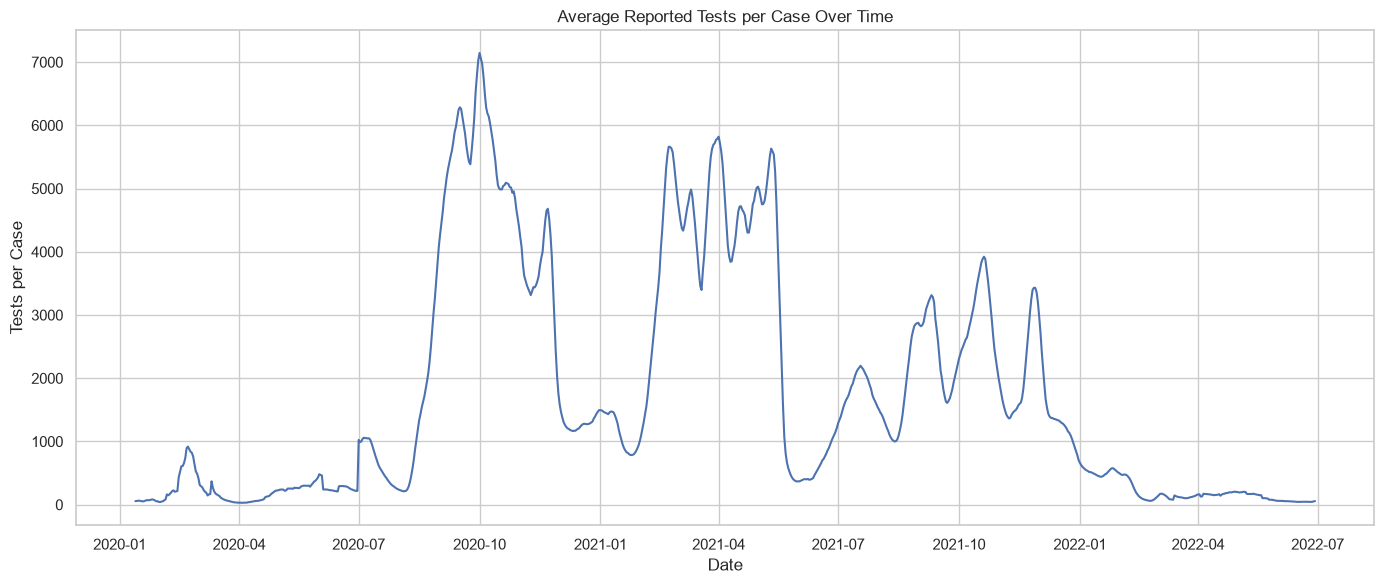

In [59]:
tests_trend = (
    covid.dropna(subset=["tests_per_case"])
    .groupby("date", as_index=False)["tests_per_case"]
    .mean()
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=tests_trend, x="date", y="tests_per_case")
plt.title("Average Reported Tests per Case Over Time")
plt.xlabel("Date")
plt.ylabel("Tests per Case")
plt.tight_layout()
plt.show()

#### ii.Countries reported the highest number of tests per capita

,country,date,tests_per_1000
121413,Cyprus,2022-04-14,22158.857453
29459,Austria,2022-06-23,20937.502579
15164,United Arab Emirates,2022-06-23,16453.941946
164420,Faroe Islands,2022-02-26,14394.141268
181189,Gibraltar,2022-04-01,14170.976057
133442,Denmark,2022-06-22,10952.227218
468760,Slovakia,2022-06-22,9361.713222
195614,Greece,2022-06-22,8113.663017
171675,United Kingdom,2022-05-19,7381.569425
212323,Hong Kong,2022-05-24,6620.313684


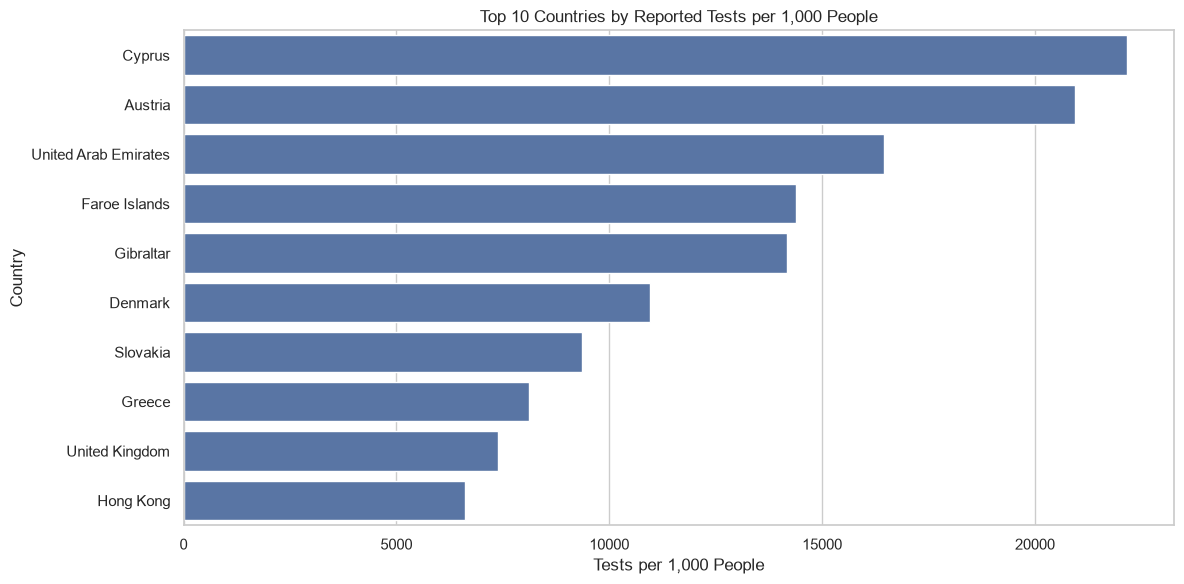

In [61]:
testing_per_capita = (
    covid.dropna(subset=["total_tests", "population"])
    .sort_values("date")
    .groupby("code", as_index=False)
    .tail(1)
    .copy()
)

testing_per_capita = testing_per_capita[
    testing_per_capita["population"] > 0
].copy()

testing_per_capita["tests_per_1000"] = (
    testing_per_capita["total_tests"] /
    testing_per_capita["population"]
) * 1000

top_testing = (
    testing_per_capita
    .sort_values("tests_per_1000", ascending=False)
    [["country", "date", "tests_per_1000"]]
    .head(10)
)

display(top_testing)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_testing,
    x="tests_per_1000",
    y="country"
)
plt.title("Top 10 Countries by Reported Tests per 1,000 People")
plt.xlabel("Tests per 1,000 People")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

#### iii.Did countries with more testing detect more cases, or is the positive rate a better indicator?

**Approach:** compare each country's average daily tests per 1,000 people with its average positive rate. A high positive rate means a country is only testing the sickest people and missing many infections. The WHO's benchmark for adequate testing is a positive rate **below 5%**; sustained rates above **10%** are a clear sign of under-testing.

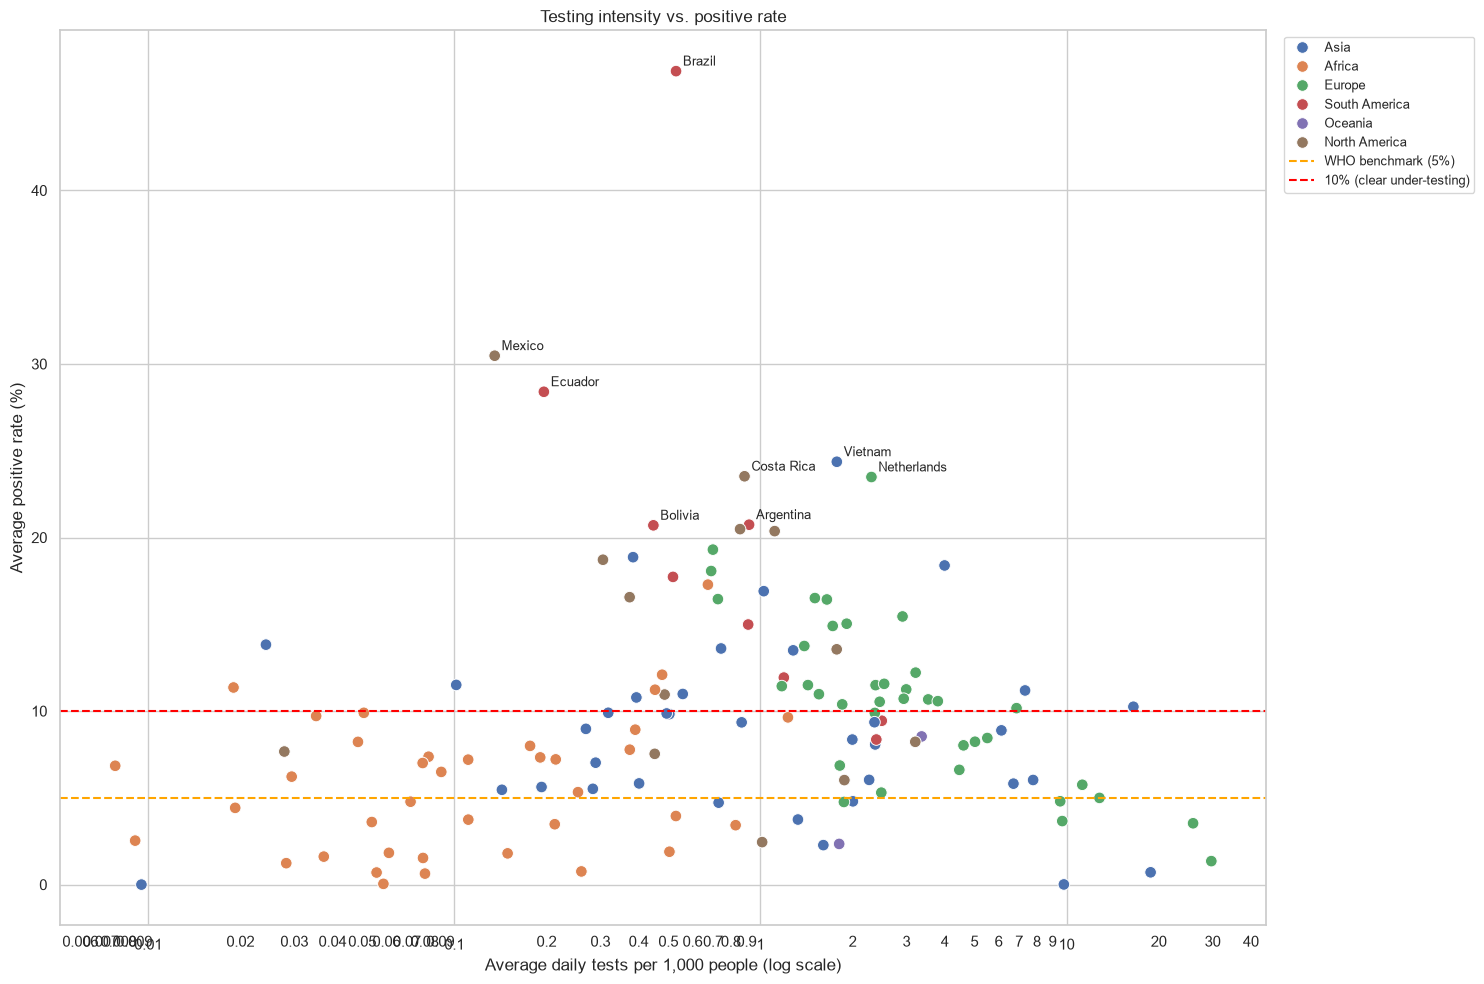

54 of 135 countries averaged a positive rate above 10%


,country,tests_per_1000,positive_rate_pct,pct_days_above_5
code,,,,
BRA,Brazil,0.53,46.87,98.35
MEX,Mexico,0.14,30.47,92.60
ECU,Ecuador,0.20,28.40,100.00
VNM,Vietnam,1.78,24.36,64.62
CRI,Costa Rica,0.89,23.53,90.10
NLD,Netherlands,2.30,23.49,83.71
ARG,Argentina,0.92,20.74,84.17
BOL,Bolivia,0.45,20.70,89.74
TTO,Trinidad and Tobago,0.86,20.48,82.84


In [62]:
t = countries.dropna(subset=["new_tests_smoothed", "positive_rate_pct"]).copy()
t = t[t["population"] >= MIN_POP]
t["tests_per_1000"] = t["new_tests_smoothed"] / t["population"] * 1000
t["above_5"] = t["positive_rate_pct"] > 5

test_country = t.groupby("code").agg(
    country=("country", "last"), continent=("continent", "last"), days=("date", "count"),
    tests_per_1000=("tests_per_1000", "mean"), positive_rate_pct=("positive_rate_pct", "mean"),
    pct_days_above_5=("above_5", "mean"),
)
test_country["pct_days_above_5"] *= 100
test_country = test_country[test_country["days"] >= 90]

plt.figure(figsize=(15, 10))
ax = sns.scatterplot(data=test_country, x="tests_per_1000", y="positive_rate_pct", hue="continent", s=70)
ax.set_xscale("log")
ax.axhline(5, color="orange", ls="--", label="WHO benchmark (5%)")
ax.axhline(10, color="red", ls="--", label="10% (clear under-testing)")
for _, r in test_country.nlargest(8, "positive_rate_pct").iterrows():
    ax.annotate(r["country"], (r["tests_per_1000"], r["positive_rate_pct"]), xytext=(5, 4), textcoords="offset points", fontsize=9)
ax.set_title("Testing intensity vs. positive rate")
ax.set_xlabel("Average daily tests per 1,000 people (log scale)")
ax.set_ylabel("Average positive rate (%)")
plain = mtick.FuncFormatter(lambda v, _: f"{v:g}")
ax.xaxis.set_major_formatter(plain)
ax.xaxis.set_minor_formatter(plain)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9)
save_fig("q16_testing_vs_positive_rate")

print(f"{(test_country['positive_rate_pct'] > 10).sum()} of {len(test_country)} countries averaged a positive rate above 10%")
display(test_country.nlargest(10, "positive_rate_pct")[["country", "tests_per_1000", "positive_rate_pct", "pct_days_above_5"]].round(2))

### Section F:Demographic and economic factors

#### i.Was GDP per capita associated with vaccination coverage

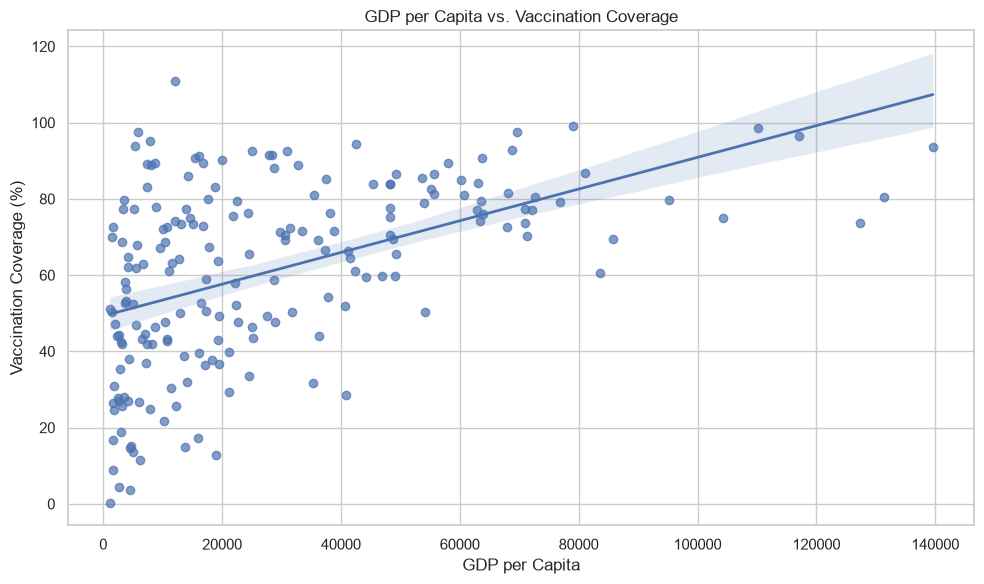

Correlation: 0.487461703111258


In [64]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=gdp_vaccination,
    x="gdp_per_capita",
    y="vaccination_coverage",
    scatter_kws={"alpha": 0.7},
    line_kws={"linewidth": 2}
)

plt.title("GDP per Capita vs. Vaccination Coverage")
plt.xlabel("GDP per Capita")
plt.ylabel("Vaccination Coverage (%)")
plt.tight_layout()
plt.show()

print(
    "Correlation:",
    gdp_vaccination["gdp_per_capita"].corr(
        gdp_vaccination["vaccination_coverage"]
    )
)

#### ii.Was population density associated with COVID-19 cases

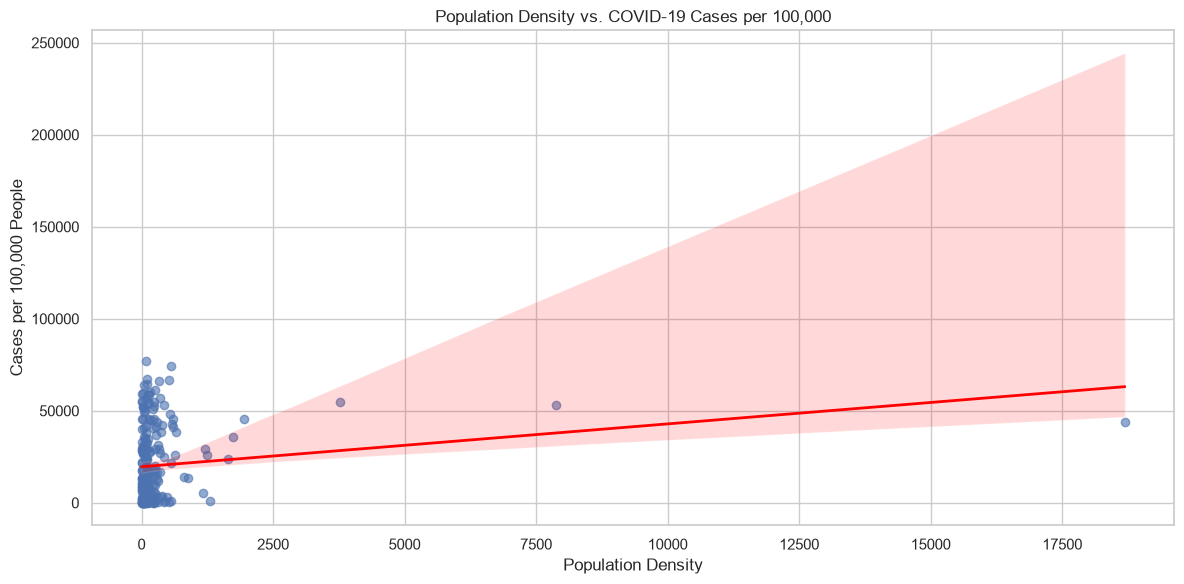

Correlation: 0.159


In [67]:
plt.figure(figsize=(12, 6))

sns.regplot(
    data=density_data,
    x="population_density",
    y="cases_per_100k",
    scatter_kws={
        "alpha": 0.6
    },
    line_kws={
        "color": "red",
        "linewidth": 2
    }
)

plt.title("Population Density vs. COVID-19 Cases per 100,000")
plt.xlabel("Population Density")
plt.ylabel("Cases per 100,000 People")

plt.tight_layout()
plt.show()

correlation = density_data["population_density"].corr(
    density_data["cases_per_100k"]
)

print(f"Correlation: {correlation:.3f}")

#### iii.Diabetes prevalence associated VS the case fatality ratio

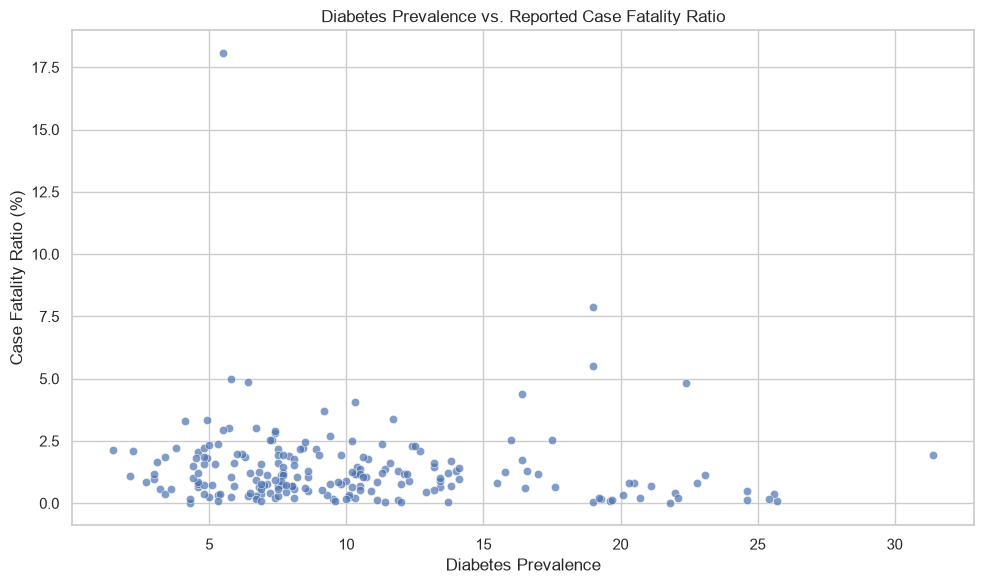

Correlation: -0.08282073450734408


In [70]:
diabetes_cfr = (
    covid.dropna(
        subset=["diabetes_prevalence", "total_cases", "total_deaths"]
    )
    .sort_values("date")
    .groupby("code", as_index=False)
    .tail(1)
    .copy()
)

diabetes_cfr = diabetes_cfr[
    diabetes_cfr["total_cases"] > 0
].copy()

diabetes_cfr["CFR"] = (
    diabetes_cfr["total_deaths"] /
    diabetes_cfr["total_cases"]
) * 100

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=diabetes_cfr,
    x="diabetes_prevalence",
    y="CFR",
    alpha=0.7
)
plt.title("Diabetes Prevalence vs. Reported Case Fatality Ratio")
plt.xlabel("Diabetes Prevalence")
plt.ylabel("Case Fatality Ratio (%)")
plt.tight_layout()
plt.show()

print(
    "Correlation:",
    diabetes_cfr["diabetes_prevalence"].corr(
        diabetes_cfr["CFR"]
    )
)

## Q20. Can countries be grouped into clusters with similar pandemic profiles

**Approach:** cluster countries with **K-Means** on four features (deaths per million, vaccination coverage, median age, GDP per capita). Skewed variables are log-transformed and all features are standardized so none dominates. The number of clusters is chosen using the **elbow method** and **silhouette score**, then the clusters are profiled and shown on an interactive world map.

C:\ProgramData\anaconda3\envs\ALX_Python\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\envs\ALX_Python\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\envs\ALX_Python\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\envs\ALX_Python\Lib\site-packages\sklearn\cluster\_kmeans.py:14

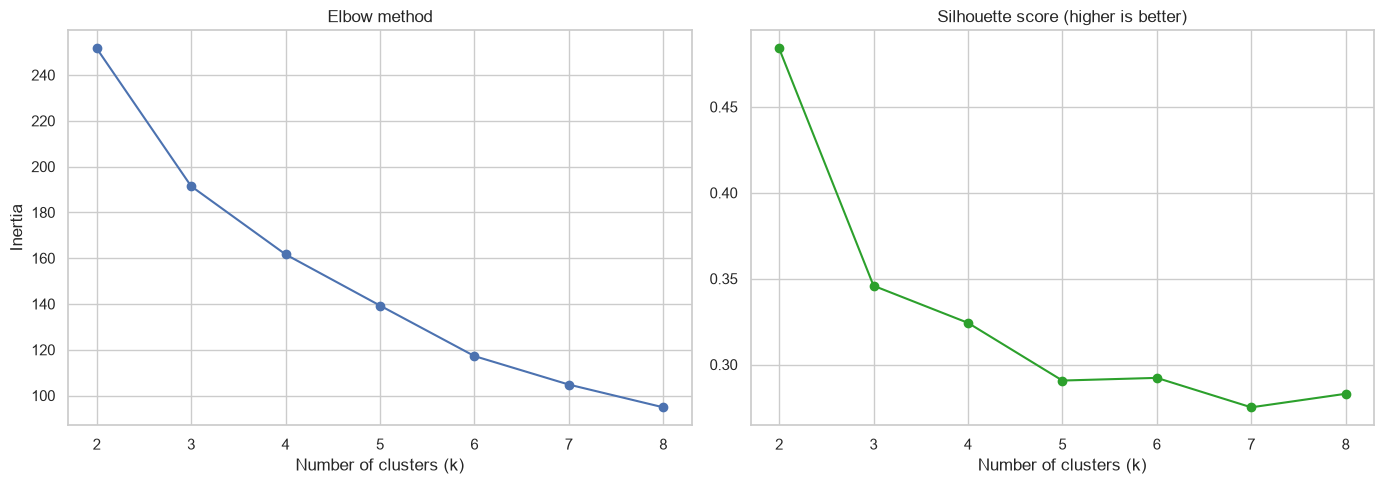

In [71]:
cluster_features = ["deaths_pm", "vacc_pct", "median_age", "gdp_per_capita"]
cl = big[["country"] + cluster_features].dropna().copy()

X_cl = cl[cluster_features].copy()
X_cl["deaths_pm"] = np.log1p(X_cl["deaths_pm"])
X_cl["gdp_per_capita"] = np.log(X_cl["gdp_per_capita"])
X_scaled = StandardScaler().fit_transform(X_cl)

ks = range(2, 9)
inertia, silhouette = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(ks), inertia, "o-")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[1].plot(list(ks), silhouette, "o-", color="tab:green")
axes[1].set_title("Silhouette score (higher is better)")
axes[1].set_xlabel("Number of clusters (k)")
save_fig("q20_choose_k")

In [72]:
# Choosing k from the silhouette curve between 3 and 6 clusters. Override K here if the elbow plot suggests otherwise.
K = max(range(3, 7), key=lambda k: silhouette[list(ks).index(k)])
print(f"Using k = {K}")

km = KMeans(n_clusters=K, n_init=10, random_state=42).fit(X_scaled)
cl["raw_cluster"] = km.labels_

# Number clusters 1..K in order of increasing deaths per million so labels are meaningful
order = cl.groupby("raw_cluster")["deaths_pm"].mean().sort_values().index
cl["cluster"] = cl["raw_cluster"].map({old: f"Cluster {i + 1}" for i, old in enumerate(order)})

profile = cl.groupby("cluster").agg(
    countries=("country", "count"),
    deaths_pm=("deaths_pm", "mean"), vacc_pct=("vacc_pct", "mean"),
    median_age=("median_age", "mean"), gdp_per_capita=("gdp_per_capita", "mean"),
).round(1)
display(profile)

for name, grp in cl.groupby("cluster"):
    print(f"{name}: {', '.join(grp['country'].head(6))}")

Using k = 3


C:\ProgramData\anaconda3\envs\ALX_Python\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,countries,deaths_pm,vacc_pct,median_age,gdp_per_capita
cluster,,,,,
Cluster 1,50,116.0,31.0,19.1,5243.5
Cluster 2,43,1452.4,56.3,28.4,15189.1
Cluster 3,57,2358.1,71.7,39.1,50784.2


Cluster 1: Afghanistan, Angola, Burundi, Benin, Burkina Faso, Central African Republic
Cluster 2: Albania, Armenia, Azerbaijan, Bangladesh, Bolivia, Botswana
Cluster 3: United Arab Emirates, Argentina, Australia, Austria, Belgium, Bulgaria


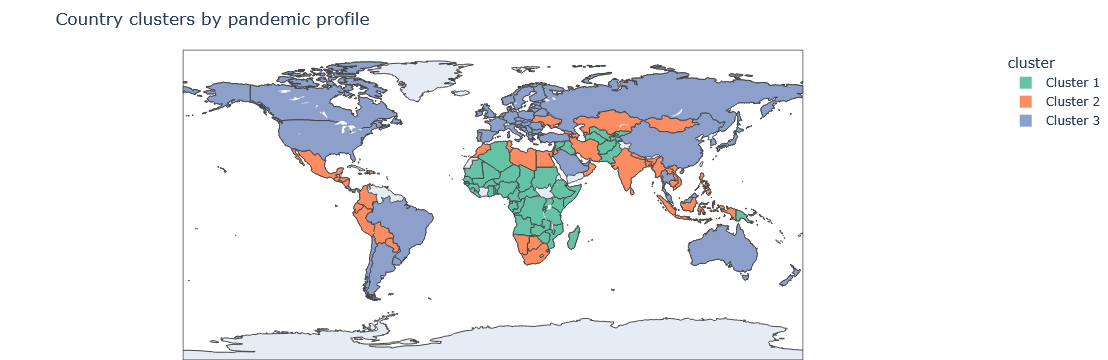

In [73]:
map_df = cl.reset_index()
map_df["code"] = map_df["code"].astype(str)

fig = px.choropleth(
    map_df, locations="code", color="cluster", hover_name="country",
    hover_data={"deaths_pm": ":.0f", "vacc_pct": ":.0f", "median_age": ":.1f", "gdp_per_capita": ":,.0f", "code": False},
    category_orders={"cluster": sorted(map_df["cluster"].unique())},
    color_discrete_sequence=px.colors.qualitative.Set2,
    title="Country clusters by pandemic profile",
)
fig.update_layout(margin=dict(l=0, r=0, t=50, b=0))
fig.write_html(FIGURES_DIR / "q20_cluster_map.html")   # interactive copy for the repo
fig.show()

# Limitations

- Reporting standards, testing capacity and case definitions differ by country, so cross-country comparisons are imperfect.
- Many countries stopped reporting after 2022, so late-period global totals understate reality.
- Hospital, ICU and testing data are available for only a subset of countries.
- Before/after comparisons and correlations show association, not causation. Variants, seasonality and policy changes overlap in time.